# Objetivo 1 — Classificação de Attrition
Modelos de classificação supervisionada para prever o atrito (`Attrition`).

**Estrutura:**
- Baseline: Árvore de Decisão 
- Candidato 1: Random Forest
- Candidato 2: Gradient Boosting
- Candidato 3: XGBoost
- Candidato 4: LightGBM
- Candidato 5: CatBoost
- Candidato 6: SVM
- Candidato 7: Árvore de Decisão com Pruning
- Candidato 8: Regressão Logística
- Candidato 9: Linear Discriminant Analysis (LDA)
- Candidato 10: Naive Bayes (GaussianNB)
- Candidato 11: K-Nearest Neighbors (KNN)
- Candidato 12: Extra Trees
- Candidato 13: Rede Neuronal MLP (sklearn)
- Candidato 14: Rede Neuronal TabNet (pytorch-tabnet)
- Candidato 15: Rede Neuronal Keras (TensorFlow)
- Candidato 16: Keras com Dropout + BatchNormalization
- Candidato 17: GANDALF (pytorch-tabular)
- Candidato 18: FT-Transformer (pytorch-tabular)

**Autores:** Figueira, L., Afonso, M., Ferreira, M.

## 0. INSTALAÇÃO DE BIBLIOTECAS

In [1]:
import subprocess
libs = ["xgboost", "lightgbm", "catboost"]
for lib in libs:
    subprocess.run(["pip", "install", lib, "-q"], check=True)
    print(f"  {lib} instalado.")
print("\nInstalação concluída.")

  xgboost instalado.
  lightgbm instalado.
  catboost instalado.

Instalação concluída.


## BASELINE — Árvore de Decisão
Modelo baseline com `DecisionTreeClassifier` (parâmetros default).

In [2]:
# 1. IMPORTAÇÕES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [3]:
# 2. CARREGAMENTO DO DATASET

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df = pd.read_csv(url)
print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")

Dataset carregado: 1470 linhas, 62 colunas


In [4]:
## 3. PREPARAÇÃO DAS FEATURES
#
#cols_remover = ["Attrition", "OverTime", "Gender",
#                "BusinessTravel", "Department", "EducationField",
#                "JobRole", "MaritalStatus"]
#
#cols_remover = [c for c in cols_remover if c in df.columns]
#df_model = df.drop(columns=cols_remover)
#
#TARGET = "Attrition_bin"
#X = df_model.drop(columns=[TARGET])
#y = df_model[TARGET]
#X = X.select_dtypes(include=[np.number])
#
#print(f"Features utilizadas: {X.shape[1]}")
#print(f"Distribuicao da variavel alvo:")
#print(y.value_counts())
#print(f"  Percentagem Yes (1): {y.mean()*100:.1f}%")

In [5]:
# 4. DIVISÃO TREINO / TESTE - Gerar
#import os
#import zipfile
#from IPython.display import FileLink, display

#treino_path = "data/processed/Objetivo1/treino"
#teste_path  = "data/processed/Objetivo1/teste"

# 80% treino, 20% teste
# stratify=y - garante a mesma proporção de Yes/No em treino e teste
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, stratify=y
#)

# Criar as pastas e guardar os splits
#os.makedirs(treino_path, exist_ok=True)
#os.makedirs(teste_path, exist_ok=True)
#X_train.to_csv(f"{treino_path}/X_train.csv", index=False)
#y_train.to_csv(f"{treino_path}/y_train.csv", index=False)
#X_test.to_csv(f"{teste_path}/X_test.csv", index=False)
#y_test.to_csv(f"{teste_path}/y_test.csv", index=False)

# Criar ZIP com a estrutura de pastas completa
#zip_path = "data/processed/Objetivo1/splits.zip"
#with zipfile.ZipFile(zip_path, "w") as zipf:
#    zipf.write(f"{treino_path}/X_train.csv", "treino/X_train.csv")
#    zipf.write(f"{treino_path}/y_train.csv", "treino/y_train.csv")
#    zipf.write(f"{teste_path}/X_test.csv",   "teste/X_test.csv")
#    zipf.write(f"{teste_path}/y_test.csv",   "teste/y_test.csv")

#print("Splits gerados! :")
#display(FileLink(zip_path))
# Autor: Figueira, L.

In [6]:
## 4. DIVISÃO TREINO / TESTE — CARREGAR DO GITHUB
#base_treino = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo1/treino"
#base_teste  = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo1/teste"
#
#X_train = pd.read_csv(f"{base_treino}/X_train.csv")
#y_train = pd.read_csv(f"{base_treino}/y_train.csv").squeeze()
#X_test  = pd.read_csv(f"{base_teste}/X_test.csv")
#y_test  = pd.read_csv(f"{base_teste}/y_test.csv").squeeze()
#
#print(f"Treino: {X_train.shape[0]} observacoes")
#print(f"Teste:  {X_test.shape[0]} observacoes")
#print(f"  % Yes treino: {y_train.mean()*100:.1f}%")
#print(f"  % Yes teste:  {y_test.mean()*100:.1f}%")
## Autor: Figueira, L.

In [7]:
# 4. DIVISÃO TREINO / TESTE — a partir do dataset completo
url_full = 'https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv'
df = pd.read_csv(url_full)

cols_remover = ["Attrition", "OverTime", "Gender",
                "BusinessTravel", "Department", "EducationField",
                "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df.columns]
df_model = df.drop(columns=cols_remover)

TARGET = "Attrition_bin"
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Features utilizadas: {X.shape[1]}")
print(f"Treino: {X_train.shape[0]} observacoes  ({y_train.mean()*100:.1f}% Yes)")
print(f"Teste:  {X_test.shape[0]} observacoes  ({y_test.mean()*100:.1f}% Yes)")
# Autor: Figueira, L.

Features utilizadas: 53
Treino: 1176 observacoes  (16.2% Yes)
Teste:  294 observacoes  (16.0% Yes)


In [8]:
# 5. TREINO DO MODELO
# DecisionTreeClassifier() — todos os parâmetros default

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

print("Modelo treinado.")
print(f"  Profundidade da arvore: {clf.get_depth()}")
print(f"  Numero de folhas:       {clf.get_n_leaves()}")

Modelo treinado.
  Profundidade da arvore: 15
  Numero de folhas:       130


In [9]:
# 6. MÉTRICAS NO TREINO

y_pred_train  = clf.predict(X_train)
y_proba_train = clf.predict_proba(X_train)[:, 1]

print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [10]:
# 7. MÉTRICAS NO TESTE

y_pred_test  = clf.predict(X_test)
y_proba_test = clf.predict_proba(X_test)[:, 1]

print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3333
  Precision: 0.2951
  Recall:    0.3830
  AUC-ROC:   0.6044

              precision    recall  f1-score   support

  Permaneceu       0.88      0.83      0.85       247
        Saiu       0.30      0.38      0.33        47

    accuracy                           0.76       294
   macro avg       0.59      0.60      0.59       294
weighted avg       0.78      0.76      0.77       294



In [11]:
# 8. TABELA COMPARATIVA TREINO vs TESTE

resultados = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)

print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados)

diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.000,1.0000
1,Teste,0.3333,0.2951,0.383,0.6044



  Diferenca F1 (treino - teste): 0.6667
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


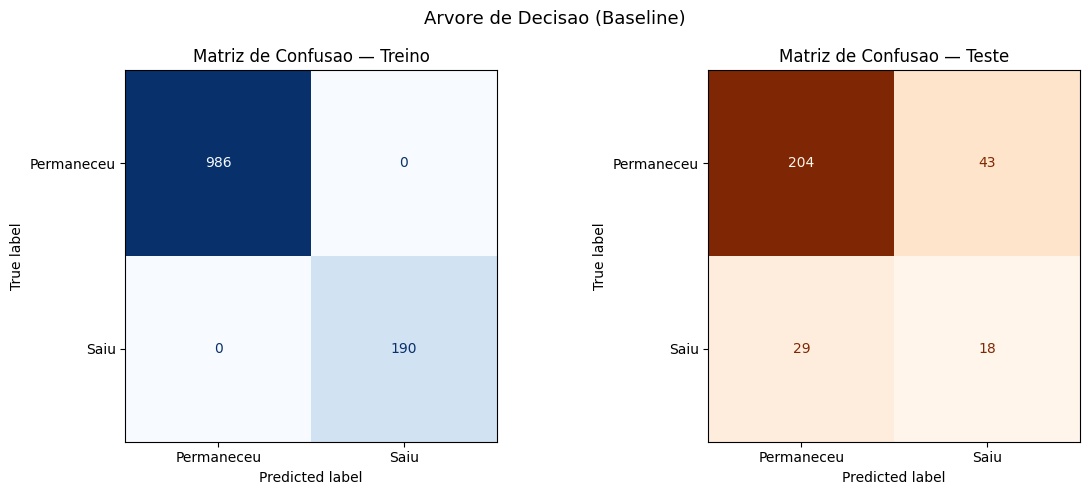

In [12]:
# 9.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_train, y_pred_train),
    display_labels=["Permaneceu", "Saiu"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_test),
    display_labels=["Permaneceu", "Saiu"]
).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Arvore de Decisao (Baseline)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

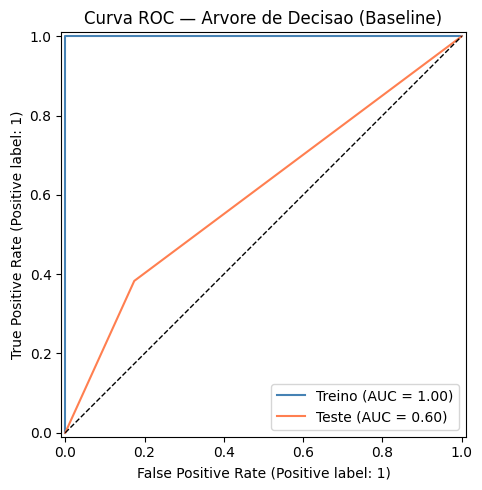

In [13]:
# 9.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Arvore de Decisao (Baseline)")
plt.tight_layout()
plt.savefig("roc_curve_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

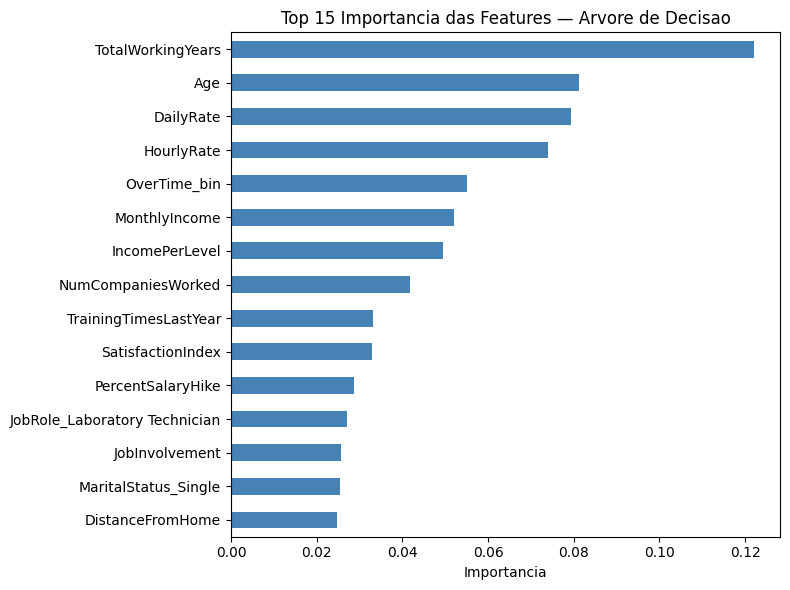

In [14]:
# 9.3 VISUALIZAÇÃO — Top 15 Importância das Features

feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Arvore de Decisao")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

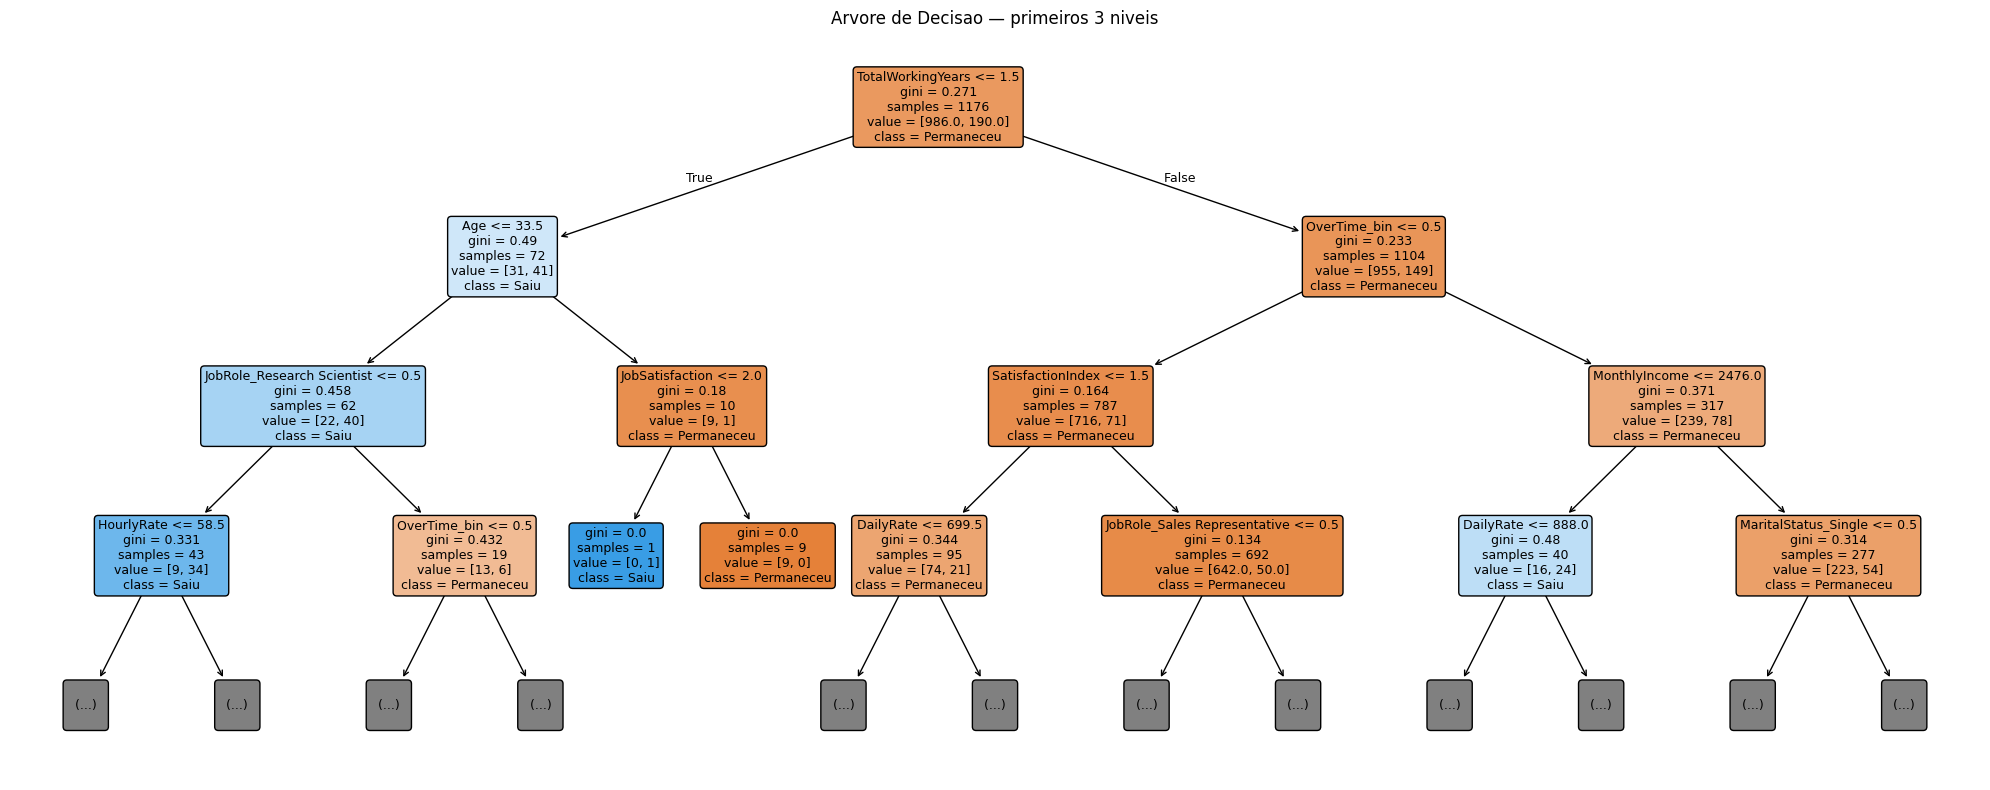

In [15]:
# 9.4 VISUALIZAÇÃO — Árvore de Decisão (primeiros 3 níveis)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf, max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=["Permaneceu", "Saiu"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Arvore de Decisao — primeiros 3 niveis")
plt.tight_layout()
plt.savefig("decision_tree_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# 10. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 204  OK
  FP — Permaneceu, previsto Saiu:       43  Erro
  FN — Saiu, previsto Permaneceu:       29  Erro (critico)
  TP — Saiu, previsto Saiu:             18  OK

  O modelo falhou em detetar 29 saidas reais (Falsos Negativos).


In [17]:
# 11. RESUMO FINAL

baseline_f1 = f1_score(y_test, y_pred_test)

print("=" * 55)
print("RESUMO — BASELINE")
print("=" * 55)
print(f"  Algoritmo:         Arvore de Decisao (parâmetros default)")
print(f"  Features:          {X.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma (nao necessaria)")
print(f"  Balanceamento:     Nenhum (baseline simples)")
print(f"  Metrica principal: F1-Score")
print(f"  Profundidade:      {clf.get_depth()} niveis")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {baseline_f1:.4f}")
print()
print("  Referencial minimo para os modelos candidatos.")
print("=" * 55)

RESUMO — BASELINE
  Algoritmo:         Arvore de Decisao (parâmetros default)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma (nao necessaria)
  Balanceamento:     Nenhum (baseline simples)
  Metrica principal: F1-Score
  Profundidade:      15 niveis

  F1 treino: 1.0000
  F1 teste:  0.3333

  Referencial minimo para os modelos candidatos.


## CANDIDATO 1 — Random Forest

In [18]:
# 1. IMPORTAÇÕES
from sklearn.ensemble import RandomForestClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [19]:
# 2. TREINO DO MODELO
clf_rf = RandomForestClassifier(random_state=42)
clf_rf.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [20]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = clf_rf.predict(X_train)
y_proba_train = clf_rf.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [21]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = clf_rf.predict(X_test)
y_proba_test = clf_rf.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.1695
  Precision: 0.4167
  Recall:    0.1064
  AUC-ROC:   0.7956

              precision    recall  f1-score   support

  Permaneceu       0.85      0.97      0.91       247
        Saiu       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



In [22]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_rf = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_rf)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.1695,0.4167,0.1064,0.7956



  Diferenca F1 (treino - teste): 0.8305
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


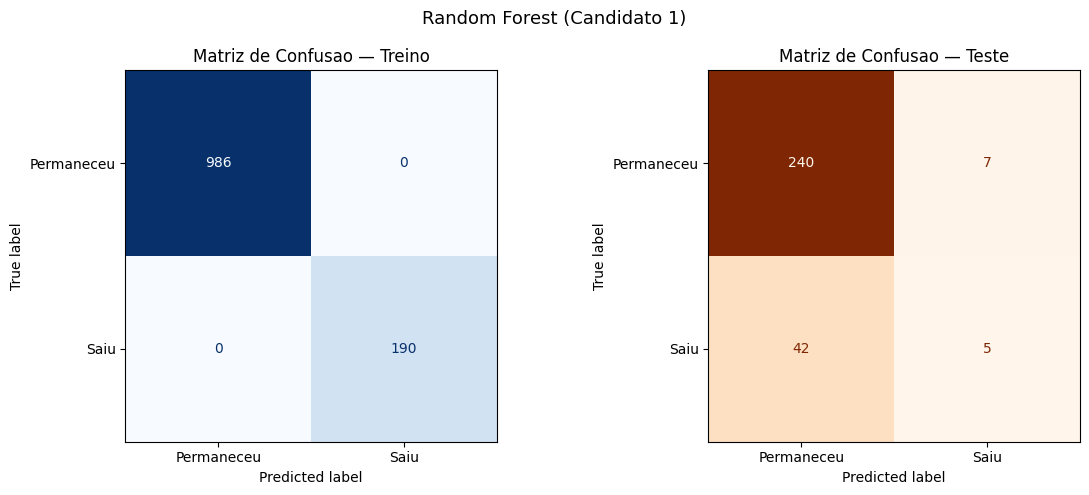

In [23]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Random Forest (Candidato 1)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()

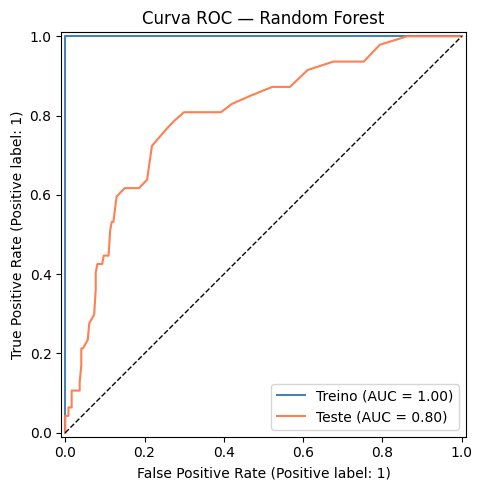

In [24]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Random Forest")
plt.tight_layout()
plt.savefig("roc_curve_rf.png", dpi=150, bbox_inches="tight")
plt.show()

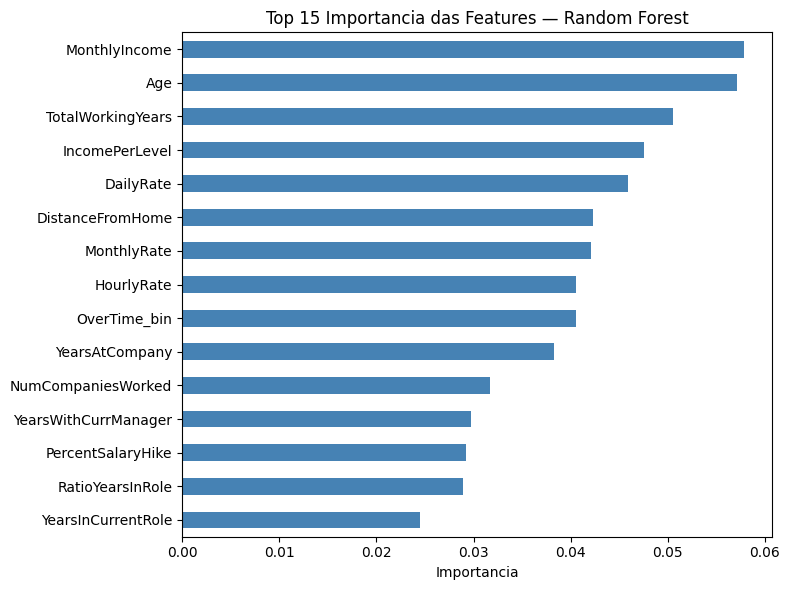

In [25]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
feat_imp = pd.Series(clf_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Random Forest")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 240  OK
  FP — Permaneceu, previsto Saiu:       7  Erro
  FN — Saiu, previsto Permaneceu:       42  Erro (critico)
  TP — Saiu, previsto Saiu:             5  OK

  O modelo falhou em detetar 42 saidas reais (Falsos Negativos).


In [27]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 1")
print("=" * 55)
print(f"  Algoritmo:         Random Forest")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 1
  Algoritmo:         Random Forest
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.1695
  Baseline:  0.3333
  Melhoria:  -0.1638


## CANDIDATO 2 — Gradient Boosting

In [28]:
# 1. IMPORTAÇÕES
from sklearn.ensemble import GradientBoostingClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [29]:
# 2. TREINO DO MODELO
clf_gb = GradientBoostingClassifier(random_state=42)
clf_gb.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [30]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = clf_gb.predict(X_train)
y_proba_train = clf_gb.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.8520
  Precision: 1.0000
  Recall:    0.7421
  AUC-ROC:   0.9855

              precision    recall  f1-score   support

  Permaneceu       0.95      1.00      0.98       986
        Saiu       1.00      0.74      0.85       190

    accuracy                           0.96      1176
   macro avg       0.98      0.87      0.91      1176
weighted avg       0.96      0.96      0.96      1176



In [31]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = clf_gb.predict(X_test)
y_proba_test = clf_gb.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3175
  Precision: 0.6250
  Recall:    0.2128
  AUC-ROC:   0.8091

              precision    recall  f1-score   support

  Permaneceu       0.87      0.98      0.92       247
        Saiu       0.62      0.21      0.32        47

    accuracy                           0.85       294
   macro avg       0.75      0.59      0.62       294
weighted avg       0.83      0.85      0.82       294



In [32]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_gb = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_gb)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.8520,1.000,0.7421,0.9855
1,Teste,0.3175,0.625,0.2128,0.8091



  Diferenca F1 (treino - teste): 0.5345
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


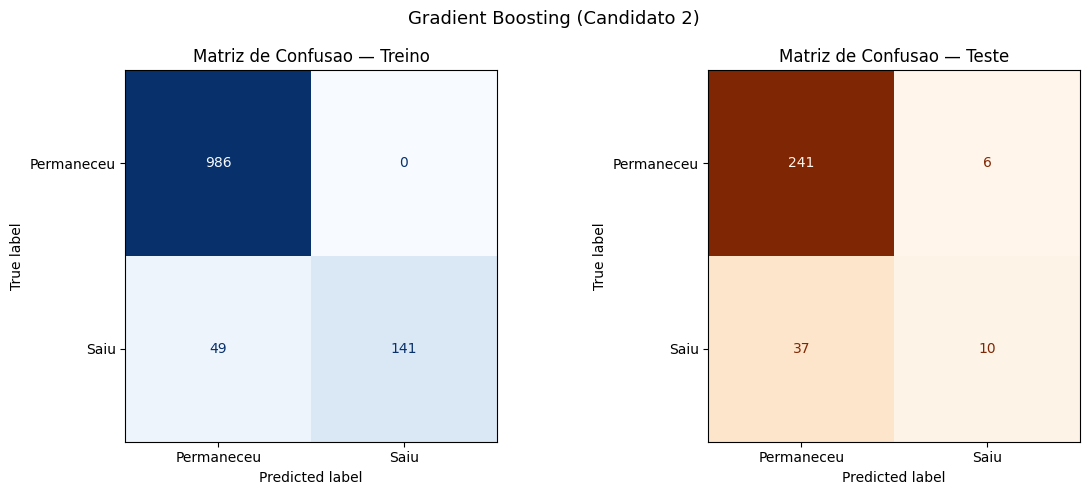

In [33]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Gradient Boosting (Candidato 2)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_gb.png", dpi=150, bbox_inches="tight")
plt.show()

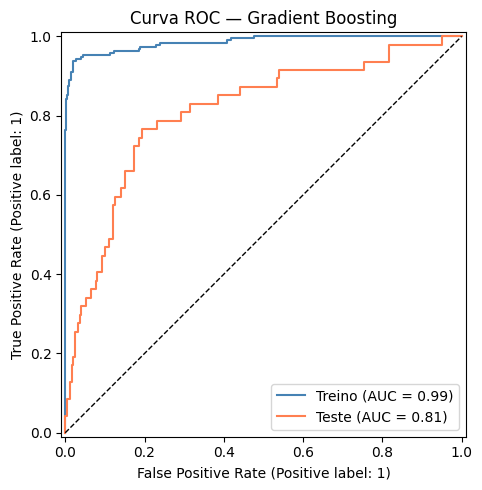

In [34]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Gradient Boosting")
plt.tight_layout()
plt.savefig("roc_curve_gb.png", dpi=150, bbox_inches="tight")
plt.show()

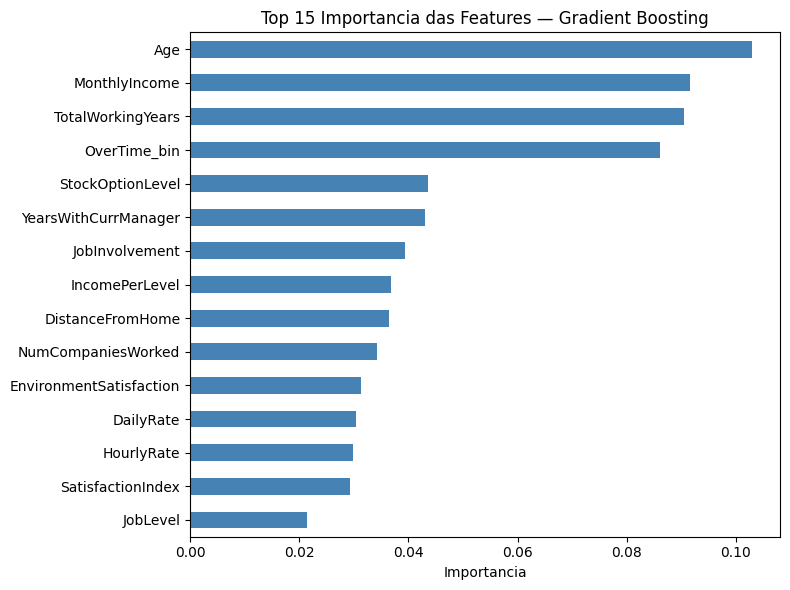

In [35]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
feat_imp = pd.Series(clf_gb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Gradient Boosting")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_gb.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 241  OK
  FP — Permaneceu, previsto Saiu:       6  Erro
  FN — Saiu, previsto Permaneceu:       37  Erro (critico)
  TP — Saiu, previsto Saiu:             10  OK

  O modelo falhou em detetar 37 saidas reais (Falsos Negativos).


In [37]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 2")
print("=" * 55)
print(f"  Algoritmo:         Gradient Boosting")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 2
  Algoritmo:         Gradient Boosting
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.8520
  F1 teste:  0.3175
  Baseline:  0.3333
  Melhoria:  -0.0159


## CANDIDATO 3 — XGBoost

In [38]:
# 1. IMPORTAÇÕES
from xgboost import XGBClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [39]:
# 2. TREINO DO MODELO
clf_xgb = XGBClassifier(random_state=42, eval_metric="logloss", use_label_encoder=False)
clf_xgb.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [40]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = clf_xgb.predict(X_train)
y_proba_train = clf_xgb.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [41]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = clf_xgb.predict(X_test)
y_proba_test = clf_xgb.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3333
  Precision: 0.5789
  Recall:    0.2340
  AUC-ROC:   0.7617

              precision    recall  f1-score   support

  Permaneceu       0.87      0.97      0.92       247
        Saiu       0.58      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.72      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294



In [42]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_xgb = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_xgb)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.000,1.0000
1,Teste,0.3333,0.5789,0.234,0.7617



  Diferenca F1 (treino - teste): 0.6667
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


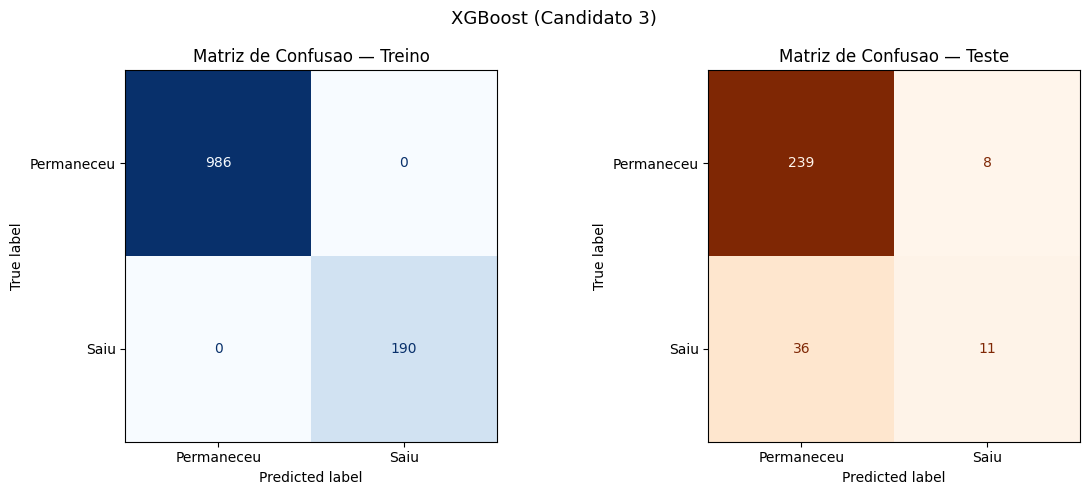

In [43]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("XGBoost (Candidato 3)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

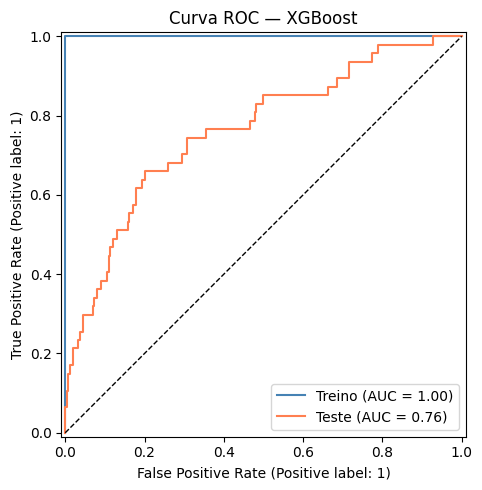

In [44]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — XGBoost")
plt.tight_layout()
plt.savefig("roc_curve_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

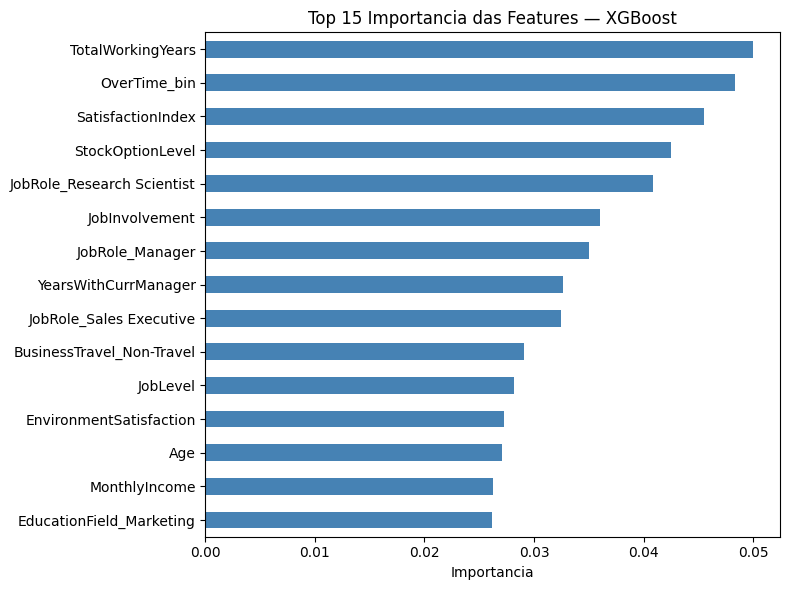

In [45]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
feat_imp = pd.Series(clf_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — XGBoost")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

In [46]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 239  OK
  FP — Permaneceu, previsto Saiu:       8  Erro
  FN — Saiu, previsto Permaneceu:       36  Erro (critico)
  TP — Saiu, previsto Saiu:             11  OK

  O modelo falhou em detetar 36 saidas reais (Falsos Negativos).


In [47]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 3")
print("=" * 55)
print(f"  Algoritmo:         XGBoost")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 3
  Algoritmo:         XGBoost
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.3333
  Baseline:  0.3333
  Melhoria:  +0.0000


## CANDIDATO 4 — LightGBM

In [48]:
# 1. IMPORTAÇÕES
from lightgbm import LGBMClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [49]:
# 2. TREINO DO MODELO
clf_lgbm = LGBMClassifier(random_state=42, verbose=-1)
clf_lgbm.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [50]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = clf_lgbm.predict(X_train)
y_proba_train = clf_lgbm.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [51]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = clf_lgbm.predict(X_test)
y_proba_test = clf_lgbm.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3548
  Precision: 0.7333
  Recall:    0.2340
  AUC-ROC:   0.7820

              precision    recall  f1-score   support

  Permaneceu       0.87      0.98      0.92       247
        Saiu       0.73      0.23      0.35        47

    accuracy                           0.86       294
   macro avg       0.80      0.61      0.64       294
weighted avg       0.85      0.86      0.83       294



In [52]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_lgbm = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_lgbm)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.000,1.000
1,Teste,0.3548,0.7333,0.234,0.782



  Diferenca F1 (treino - teste): 0.6452
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


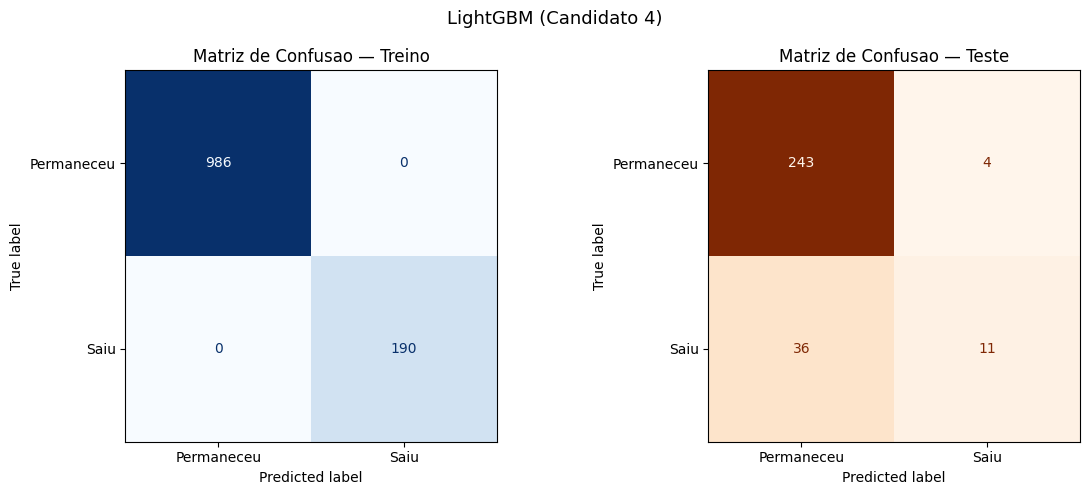

In [53]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("LightGBM (Candidato 4)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

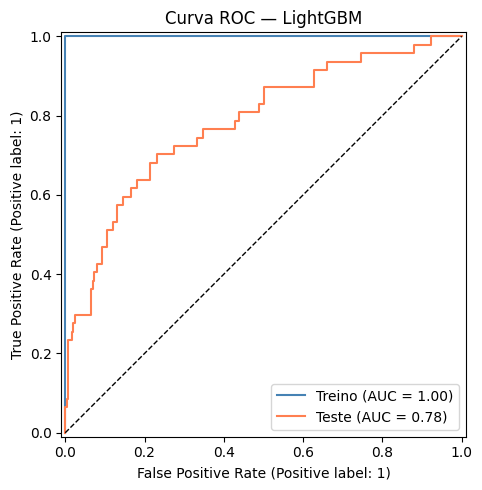

In [54]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — LightGBM")
plt.tight_layout()
plt.savefig("roc_curve_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

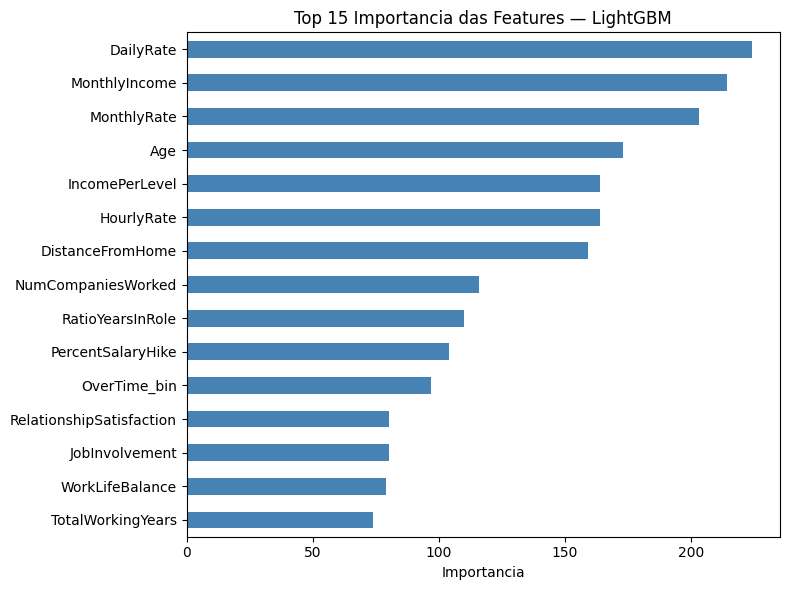

In [55]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
feat_imp = pd.Series(clf_lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — LightGBM")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 243  OK
  FP — Permaneceu, previsto Saiu:       4  Erro
  FN — Saiu, previsto Permaneceu:       36  Erro (critico)
  TP — Saiu, previsto Saiu:             11  OK

  O modelo falhou em detetar 36 saidas reais (Falsos Negativos).


In [57]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 4")
print("=" * 55)
print(f"  Algoritmo:         LightGBM")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 4
  Algoritmo:         LightGBM
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.3548
  Baseline:  0.3333
  Melhoria:  +0.0215


## CANDIDATO 5 — CatBoost

In [58]:
# 1. IMPORTAÇÕES
from catboost import CatBoostClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [59]:
# 2. TREINO DO MODELO
clf_cat = CatBoostClassifier(random_state=42, verbose=0)
clf_cat.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [60]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = clf_cat.predict(X_train)
y_proba_train = clf_cat.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.9532
  Precision: 1.0000
  Recall:    0.9105
  AUC-ROC:   0.9999

              precision    recall  f1-score   support

  Permaneceu       0.98      1.00      0.99       986
        Saiu       1.00      0.91      0.95       190

    accuracy                           0.99      1176
   macro avg       0.99      0.96      0.97      1176
weighted avg       0.99      0.99      0.99      1176



In [61]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = clf_cat.predict(X_test)
y_proba_test = clf_cat.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.2667
  Precision: 0.6154
  Recall:    0.1702
  AUC-ROC:   0.8017

              precision    recall  f1-score   support

  Permaneceu       0.86      0.98      0.92       247
        Saiu       0.62      0.17      0.27        47

    accuracy                           0.85       294
   macro avg       0.74      0.57      0.59       294
weighted avg       0.82      0.85      0.81       294



In [62]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_cat = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_cat)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.9532,1.0000,0.9105,0.9999
1,Teste,0.2667,0.6154,0.1702,0.8017



  Diferenca F1 (treino - teste): 0.6865
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


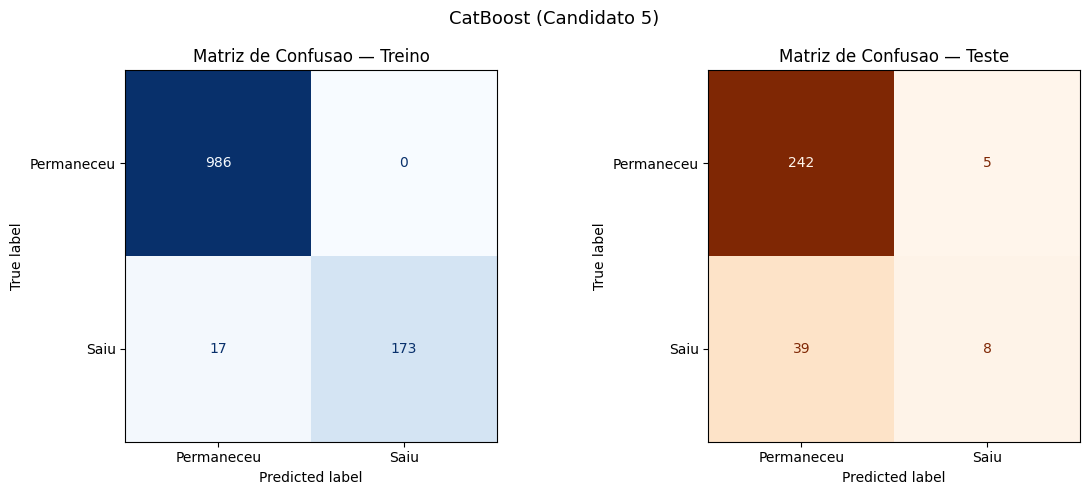

In [63]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("CatBoost (Candidato 5)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_cat.png", dpi=150, bbox_inches="tight")
plt.show()

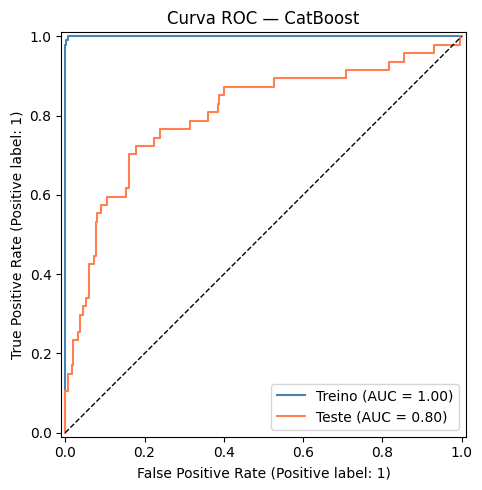

In [64]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — CatBoost")
plt.tight_layout()
plt.savefig("roc_curve_cat.png", dpi=150, bbox_inches="tight")
plt.show()

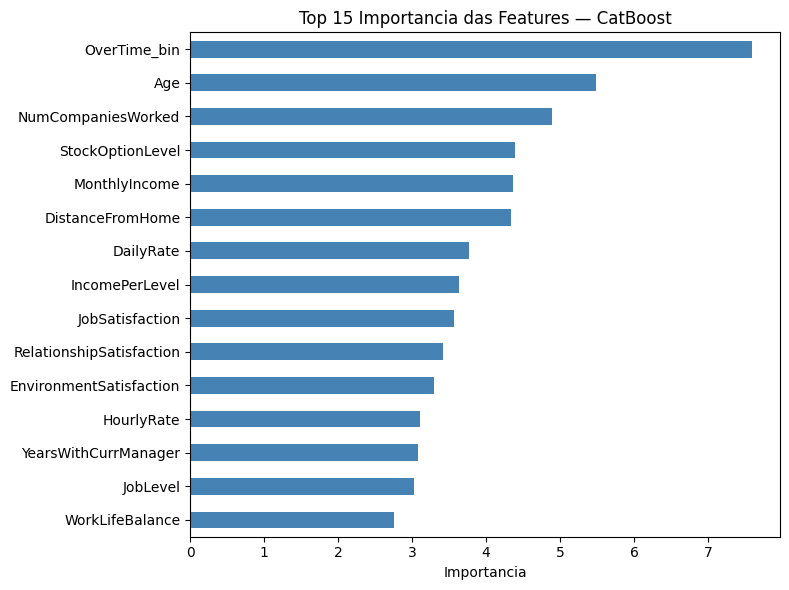

In [65]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
feat_imp = pd.Series(clf_cat.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — CatBoost")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_cat.png", dpi=150, bbox_inches="tight")
plt.show()

In [66]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 242  OK
  FP — Permaneceu, previsto Saiu:       5  Erro
  FN — Saiu, previsto Permaneceu:       39  Erro (critico)
  TP — Saiu, previsto Saiu:             8  OK

  O modelo falhou em detetar 39 saidas reais (Falsos Negativos).


In [67]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 5")
print("=" * 55)
print(f"  Algoritmo:         CatBoost")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 5
  Algoritmo:         CatBoost
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.9532
  F1 teste:  0.2667
  Baseline:  0.3333
  Melhoria:  -0.0667


## CANDIDATO 6 — SVM

In [68]:
# 1. IMPORTAÇÕES
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [69]:
# 2. TREINO DO MODELO
# SVM requer normalização — Pipeline garante que o scaler
# é ajustado só no treino, sem data leakage
# probability=True necessário para predict_proba()
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    SVC(probability=True, random_state=42))
])
pipeline_svm.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [70]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = pipeline_svm.predict(X_train)
y_proba_train = pipeline_svm.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6851
  Precision: 1.0000
  Recall:    0.5211
  AUC-ROC:   0.9654

              precision    recall  f1-score   support

  Permaneceu       0.92      1.00      0.96       986
        Saiu       1.00      0.52      0.69       190

    accuracy                           0.92      1176
   macro avg       0.96      0.76      0.82      1176
weighted avg       0.93      0.92      0.91      1176



In [71]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = pipeline_svm.predict(X_test)
y_proba_test = pipeline_svm.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.2712
  Precision: 0.6667
  Recall:    0.1702
  AUC-ROC:   0.8086

              precision    recall  f1-score   support

  Permaneceu       0.86      0.98      0.92       247
        Saiu       0.67      0.17      0.27        47

    accuracy                           0.85       294
   macro avg       0.76      0.58      0.59       294
weighted avg       0.83      0.85      0.82       294



In [72]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_svm = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_svm)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6851,1.0000,0.5211,0.9654
1,Teste,0.2712,0.6667,0.1702,0.8086



  Diferenca F1 (treino - teste): 0.4139
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


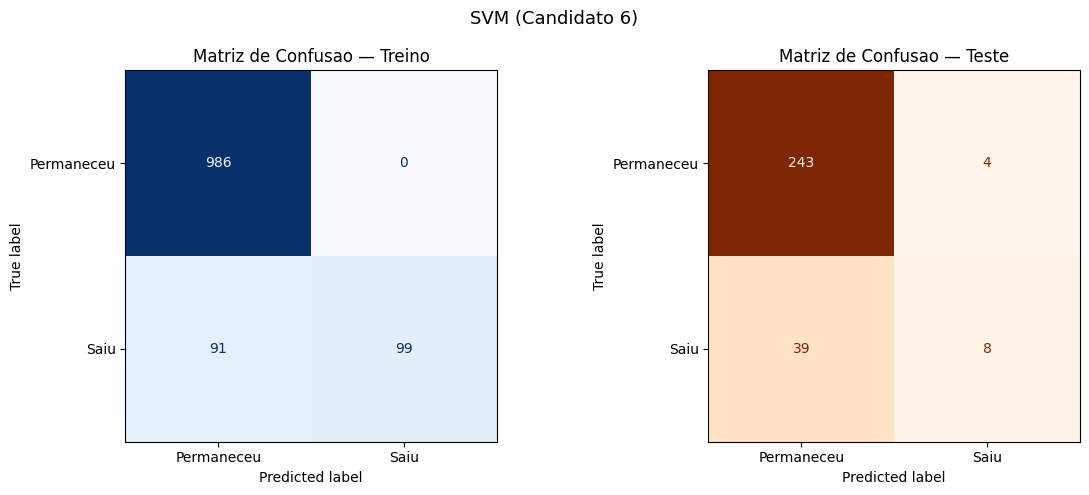

In [73]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("SVM (Candidato 6)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150, bbox_inches="tight")
plt.show()

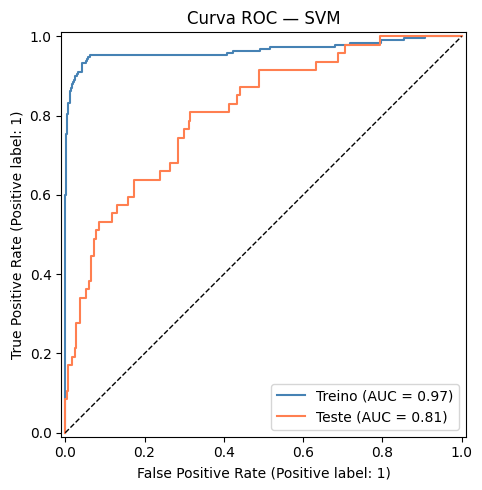

In [74]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — SVM")
plt.tight_layout()
plt.savefig("roc_curve_svm.png", dpi=150, bbox_inches="tight")
plt.show()

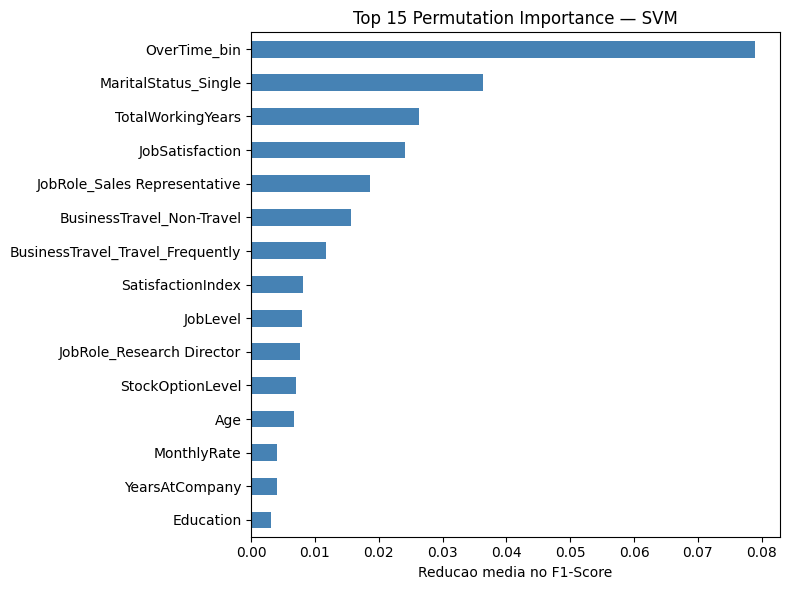

In [75]:
# 6.3 VISUALIZAÇÃO — Permutation Importance (SVM)
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    pipeline_svm, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

feat_imp = pd.Series(perm.importances_mean, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Permutation Importance — SVM")
ax.set_xlabel("Reducao media no F1-Score")
plt.tight_layout()
plt.savefig("feature_importance_svm.png", dpi=150, bbox_inches="tight")
plt.show()

In [76]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 243  OK
  FP — Permaneceu, previsto Saiu:       4  Erro
  FN — Saiu, previsto Permaneceu:       39  Erro (critico)
  TP — Saiu, previsto Saiu:             8  OK

  O modelo falhou em detetar 39 saidas reais (Falsos Negativos).


In [77]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 6")
print("=" * 55)
print(f"  Algoritmo:         SVM (kernel RBF)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler (obrigatoria para SVM)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 6
  Algoritmo:         SVM (kernel RBF)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler (obrigatoria para SVM)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6851
  F1 teste:  0.2712
  Baseline:  0.3333
  Melhoria:  -0.0621


## CANDIDATO 7 — Árvore de Decisão com Pruning

In [78]:
# 1. IMPORTAÇÕES
from sklearn.tree import DecisionTreeClassifier, plot_tree
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [79]:
# 2. TREINO DO MODELO
# ccp_alpha controla o nivel de poda
# quanto maior o valor, mais simples fica a arvore
# objetivo: reduzir o overfitting do baseline
clf_pruned = DecisionTreeClassifier(ccp_alpha=0.005, random_state=42)
clf_pruned.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Profundidade da arvore: {clf_pruned.get_depth()}")
print(f"  Numero de folhas:       {clf_pruned.get_n_leaves()}")
print(f"  ccp_alpha:              {clf_pruned.ccp_alpha}")

Modelo treinado.
  Profundidade da arvore: 4
  Numero de folhas:       5
  ccp_alpha:              0.005


In [80]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = clf_pruned.predict(X_train)
y_proba_train = clf_pruned.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.4305
  Precision: 0.5804
  Recall:    0.3421
  AUC-ROC:   0.7184

              precision    recall  f1-score   support

  Permaneceu       0.88      0.95      0.92       986
        Saiu       0.58      0.34      0.43       190

    accuracy                           0.85      1176
   macro avg       0.73      0.65      0.67      1176
weighted avg       0.83      0.85      0.84      1176



In [81]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = clf_pruned.predict(X_test)
y_proba_test = clf_pruned.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3117
  Precision: 0.4000
  Recall:    0.2553
  AUC-ROC:   0.7272

              precision    recall  f1-score   support

  Permaneceu       0.87      0.93      0.90       247
        Saiu       0.40      0.26      0.31        47

    accuracy                           0.82       294
   macro avg       0.63      0.59      0.60       294
weighted avg       0.79      0.82      0.80       294



In [82]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_pruned = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_pruned)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.4305,0.5804,0.3421,0.7184
1,Teste,0.3117,0.4000,0.2553,0.7272



  Diferenca F1 (treino - teste): 0.1188
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


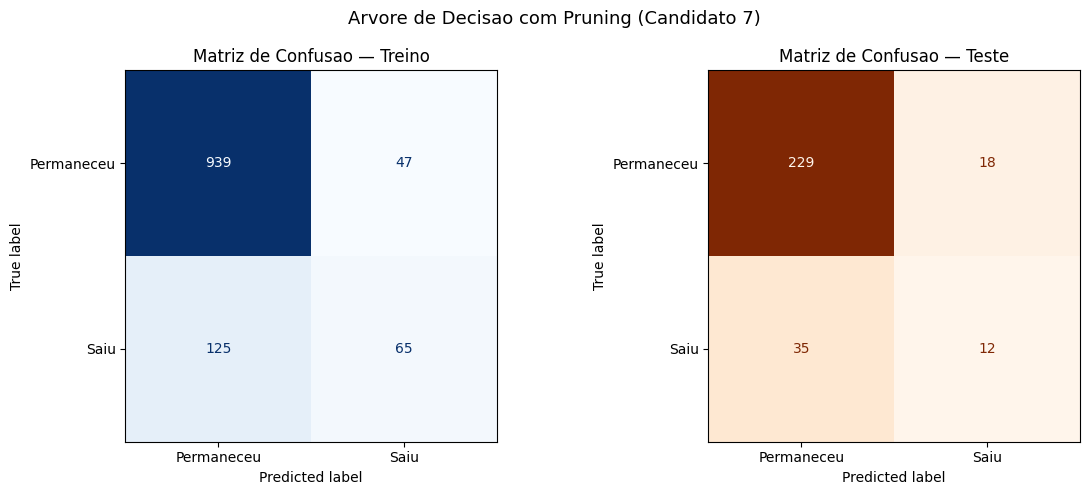

In [83]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Arvore de Decisao com Pruning (Candidato 7)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

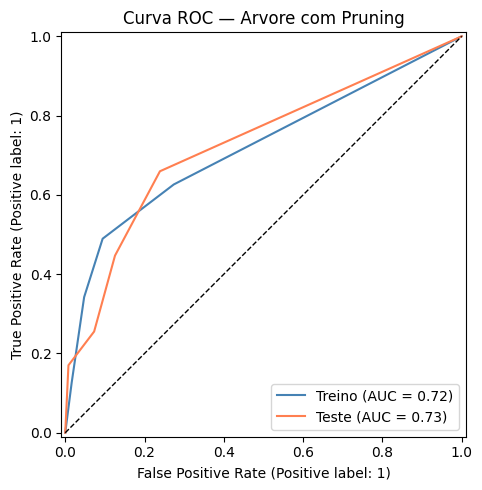

In [84]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Arvore com Pruning")
plt.tight_layout()
plt.savefig("roc_curve_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

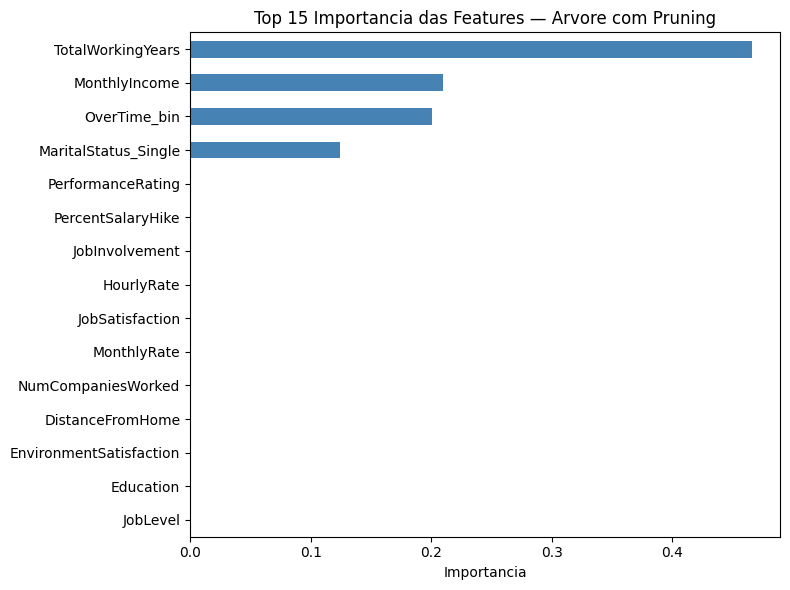

In [85]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
feat_imp = pd.Series(clf_pruned.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Arvore com Pruning")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

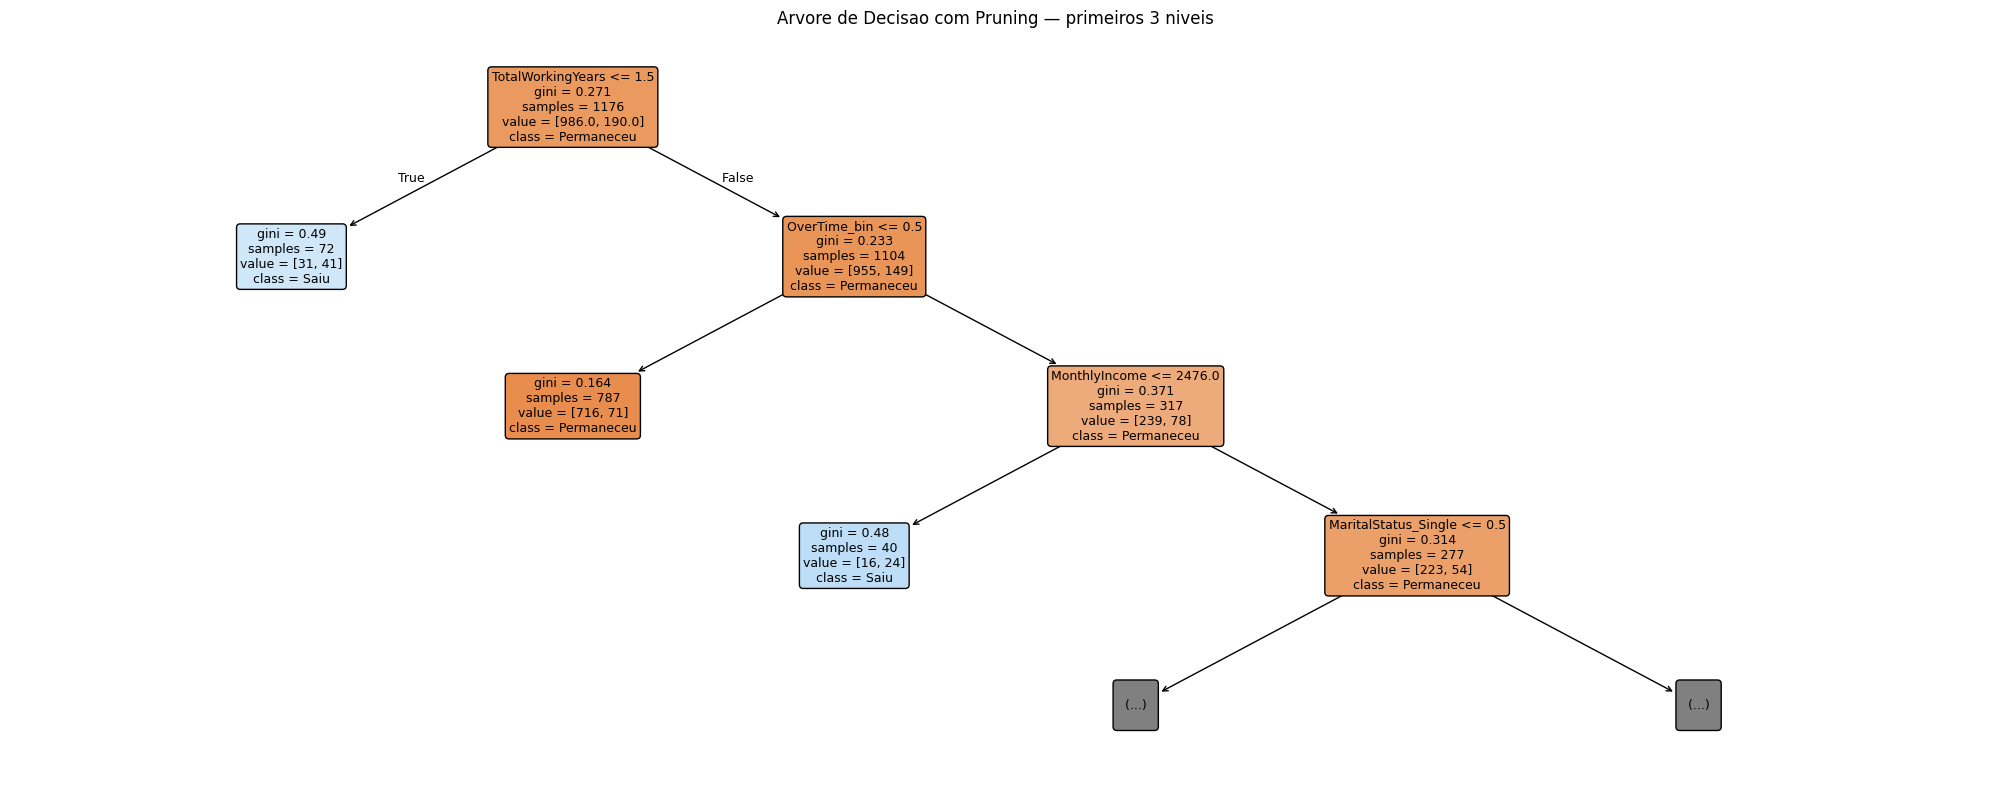

In [86]:
# 6.4 VISUALIZAÇÃO — Árvore de Decisão com Pruning (primeiros 3 níveis)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf_pruned, max_depth=3,
    feature_names=X_train.columns.tolist(),
    class_names=["Permaneceu", "Saiu"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Arvore de Decisao com Pruning — primeiros 3 niveis")
plt.tight_layout()
plt.savefig("decision_tree_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

In [87]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 229  OK
  FP — Permaneceu, previsto Saiu:       18  Erro
  FN — Saiu, previsto Permaneceu:       35  Erro (critico)
  TP — Saiu, previsto Saiu:             12  OK

  O modelo falhou em detetar 35 saidas reais (Falsos Negativos).


In [88]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 7")
print("=" * 55)
print(f"  Algoritmo:         Arvore de Decisao com Pruning")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  ccp_alpha:         {clf_pruned.ccp_alpha}")
print(f"  Profundidade:      {clf_pruned.get_depth()} niveis")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 7
  Algoritmo:         Arvore de Decisao com Pruning
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  ccp_alpha:         0.005
  Profundidade:      4 niveis
  Metrica principal: F1-Score

  F1 treino: 0.4305
  F1 teste:  0.3117
  Baseline:  0.3333
  Melhoria:  -0.0216


## CANDIDATO 8 — Regressão Logística

In [89]:
# 1. IMPORTAÇÕES
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [90]:
# 2. TREINO DO MODELO
# Pipeline com normalização (necessário para regressão logística)
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(random_state=42))
])
pipeline_lr.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Coeficientes: {pipeline_lr.named_steps['clf'].coef_.shape}")

Modelo treinado.
  Coeficientes: (1, 53)


In [91]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = pipeline_lr.predict(X_train)
y_proba_train = pipeline_lr.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6519
  Precision: 0.8175
  Recall:    0.5421
  AUC-ROC:   0.8819

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       986
        Saiu       0.82      0.54      0.65       190

    accuracy                           0.91      1176
   macro avg       0.87      0.76      0.80      1176
weighted avg       0.90      0.91      0.90      1176



In [92]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = pipeline_lr.predict(X_test)
y_proba_test = pipeline_lr.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4595
  Precision: 0.6296
  Recall:    0.3617
  AUC-ROC:   0.8170

              precision    recall  f1-score   support

  Permaneceu       0.89      0.96      0.92       247
        Saiu       0.63      0.36      0.46        47

    accuracy                           0.86       294
   macro avg       0.76      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294



In [93]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_lr = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_lr)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6519,0.8175,0.5421,0.8819
1,Teste,0.4595,0.6296,0.3617,0.8170



  Diferenca F1 (treino - teste): 0.1924
  --> Sinal de OVERFITTING.


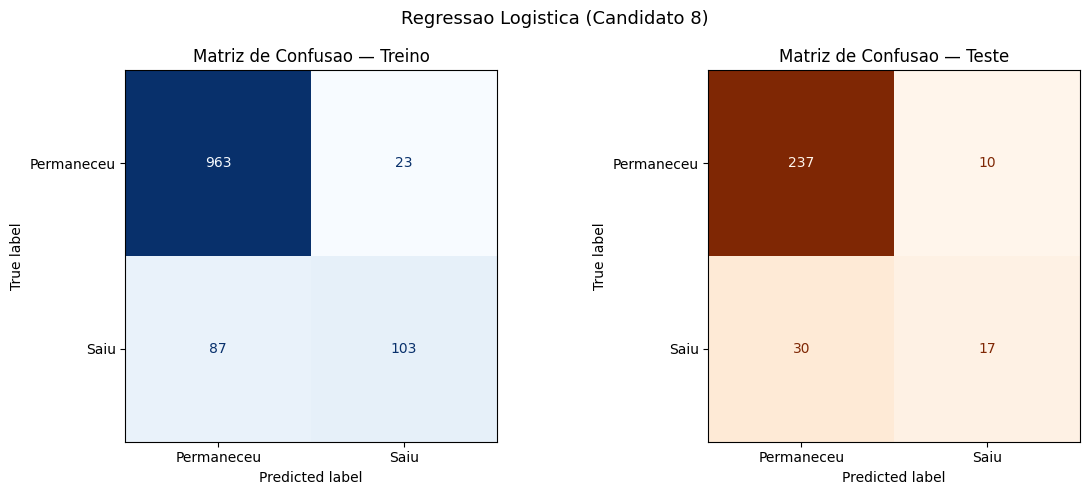

In [94]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Regressao Logistica (Candidato 8)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_lr.png", dpi=150, bbox_inches="tight")
plt.show()

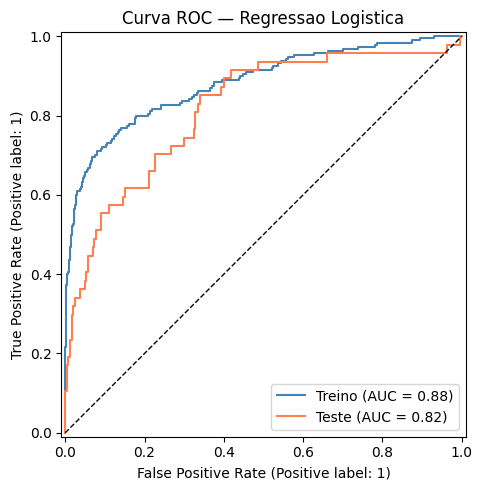

In [95]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Regressao Logistica")
plt.tight_layout()
plt.savefig("roc_curve_lr.png", dpi=150, bbox_inches="tight")
plt.show()

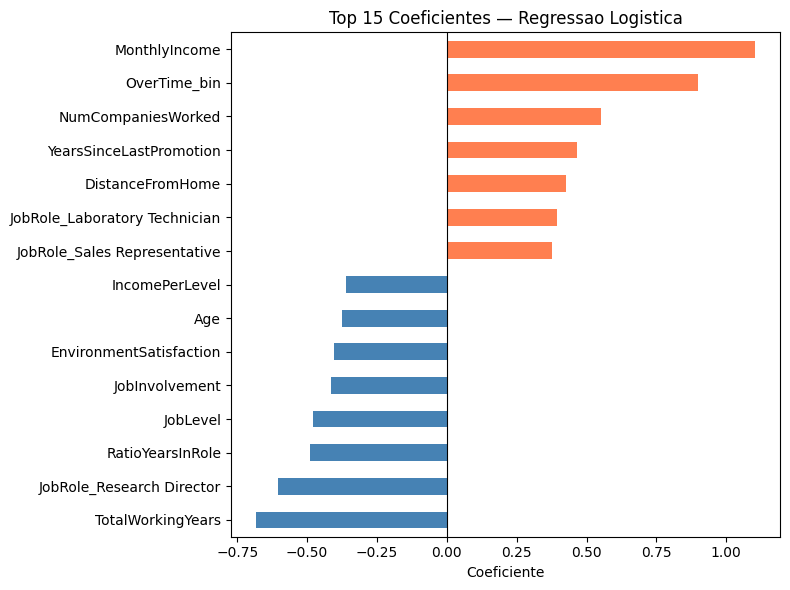

In [96]:
# 6.3 VISUALIZAÇÃO — Top 15 Coeficientes (interpretabilidade)
coef = pd.Series(
    pipeline_lr.named_steps["clf"].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
coef.sort_values().plot(kind="barh", ax=ax, color=["coral" if v > 0 else "steelblue" for v in coef.sort_values()])
ax.set_title("Top 15 Coeficientes — Regressao Logistica")
ax.set_xlabel("Coeficiente")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.savefig("coef_lr.png", dpi=150, bbox_inches="tight")
plt.show()

In [97]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 237  OK
  FP — Permaneceu, previsto Saiu:       10  Erro
  FN — Saiu, previsto Permaneceu:       30  Erro (critico)
  TP — Saiu, previsto Saiu:             17  OK

  O modelo falhou em detetar 30 saidas reais (Falsos Negativos).


In [98]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 8")
print("=" * 55)
print(f"  Algoritmo:         Regressao Logistica")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 8
  Algoritmo:         Regressao Logistica
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6519
  F1 teste:  0.4595
  Baseline:  0.3333
  Melhoria:  +0.1261


## CANDIDATO 9 — Linear Discriminant Analysis (LDA)

In [99]:
# 1. IMPORTAÇÕES
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [100]:
# 2. TREINO DO MODELO
clf_lda = LinearDiscriminantAnalysis()
clf_lda.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Componentes discriminantes: {clf_lda.scalings_.shape}")

Modelo treinado.
  Componentes discriminantes: (53, 1)


In [101]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = clf_lda.predict(X_train)
y_proba_train = clf_lda.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6454
  Precision: 0.8211
  Recall:    0.5316
  AUC-ROC:   0.8735

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       986
        Saiu       0.82      0.53      0.65       190

    accuracy                           0.91      1176
   macro avg       0.87      0.75      0.80      1176
weighted avg       0.90      0.91      0.90      1176



In [102]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = clf_lda.predict(X_test)
y_proba_test = clf_lda.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4167
  Precision: 0.6000
  Recall:    0.3191
  AUC-ROC:   0.8099

              precision    recall  f1-score   support

  Permaneceu       0.88      0.96      0.92       247
        Saiu       0.60      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.74      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294



In [103]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_lda = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_lda)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6454,0.8211,0.5316,0.8735
1,Teste,0.4167,0.6000,0.3191,0.8099



  Diferenca F1 (treino - teste): 0.2287
  --> Sinal de OVERFITTING.


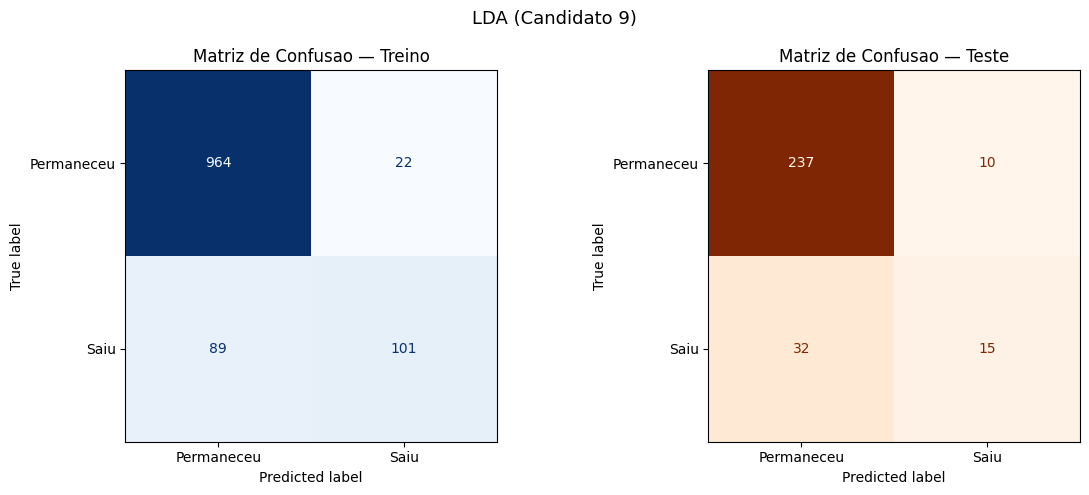

In [104]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("LDA (Candidato 9)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_lda.png", dpi=150, bbox_inches="tight")
plt.show()

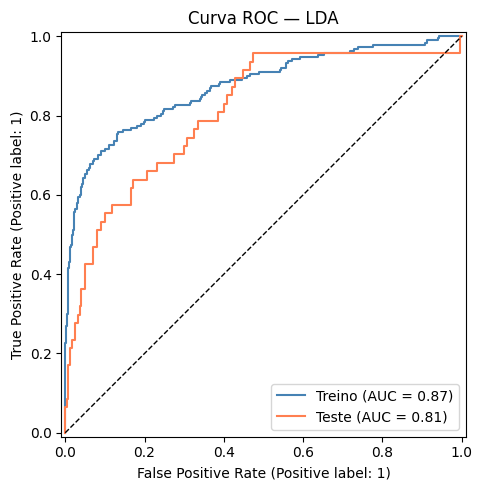

In [105]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — LDA")
plt.tight_layout()
plt.savefig("roc_curve_lda.png", dpi=150, bbox_inches="tight")
plt.show()

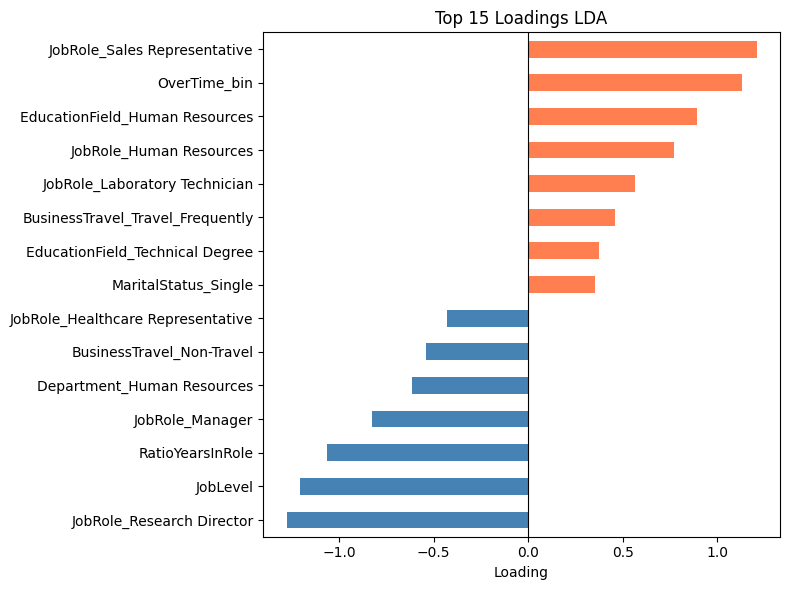

In [106]:
# 6.3 VISUALIZAÇÃO — Top 15 Loadings LDA (interpretabilidade)
loadings = pd.Series(clf_lda.scalings_[:, 0], index=X_train.columns).sort_values(key=abs, ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
loadings.sort_values().plot(kind="barh", ax=ax, color=["coral" if v > 0 else "steelblue" for v in loadings.sort_values()])
ax.set_title("Top 15 Loadings LDA")
ax.set_xlabel("Loading")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.savefig("loadings_lda.png", dpi=150, bbox_inches="tight")
plt.show()

In [107]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 237  OK
  FP — Permaneceu, previsto Saiu:       10  Erro
  FN — Saiu, previsto Permaneceu:       32  Erro (critico)
  TP — Saiu, previsto Saiu:             15  OK

  O modelo falhou em detetar 32 saidas reais (Falsos Negativos).


In [108]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 9")
print("=" * 55)
print(f"  Algoritmo:         Linear Discriminant Analysis")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma (LDA faz internamente)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 9
  Algoritmo:         Linear Discriminant Analysis
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma (LDA faz internamente)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6454
  F1 teste:  0.4167
  Baseline:  0.3333
  Melhoria:  +0.0833


## CANDIDATO 10 — Naive Bayes (GaussianNB)

In [109]:
# 1. IMPORTAÇÕES
from sklearn.naive_bayes import GaussianNB
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [110]:
# 2. TREINO DO MODELO
clf_nb = GaussianNB()
clf_nb.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Classes: {clf_nb.classes_}")
print(f"  Probabilidades a priori: {clf_nb.class_prior_.round(3)}")

Modelo treinado.
  Classes: [0 1]
  Probabilidades a priori: [0.838 0.162]


In [111]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = clf_nb.predict(X_train)
y_proba_train = clf_nb.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.4752
  Precision: 0.3583
  Recall:    0.7053
  AUC-ROC:   0.7956

              precision    recall  f1-score   support

  Permaneceu       0.93      0.76      0.83       986
        Saiu       0.36      0.71      0.48       190

    accuracy                           0.75      1176
   macro avg       0.64      0.73      0.65      1176
weighted avg       0.84      0.75      0.78      1176



In [112]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = clf_nb.predict(X_test)
y_proba_test = clf_nb.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4354
  Precision: 0.3200
  Recall:    0.6809
  AUC-ROC:   0.7269

              precision    recall  f1-score   support

  Permaneceu       0.92      0.72      0.81       247
        Saiu       0.32      0.68      0.44        47

    accuracy                           0.72       294
   macro avg       0.62      0.70      0.62       294
weighted avg       0.83      0.72      0.75       294



In [113]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_nb = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_nb)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.4752,0.3583,0.7053,0.7956
1,Teste,0.4354,0.3200,0.6809,0.7269



  Diferenca F1 (treino - teste): 0.0398
  --> Sem sinais evidentes de overfitting.


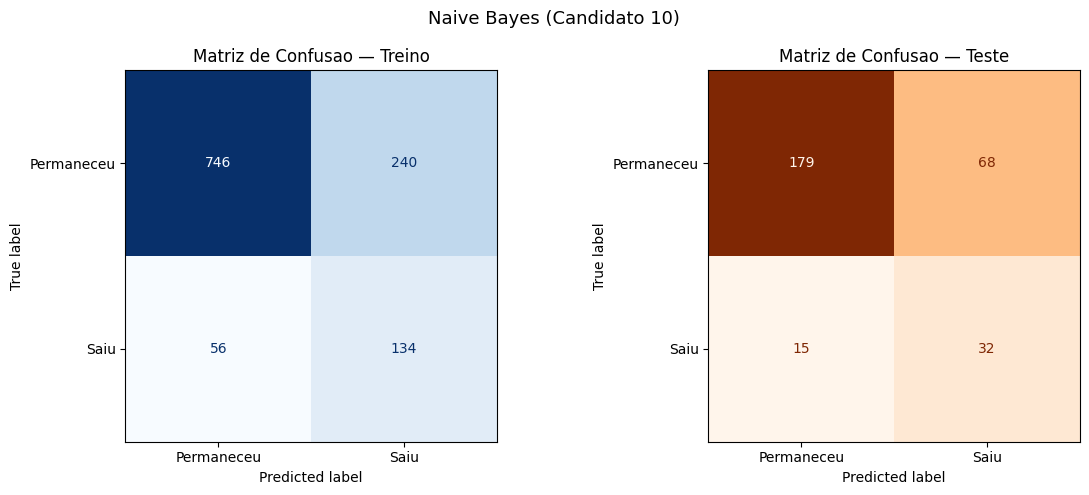

In [114]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Naive Bayes (Candidato 10)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_nb.png", dpi=150, bbox_inches="tight")
plt.show()

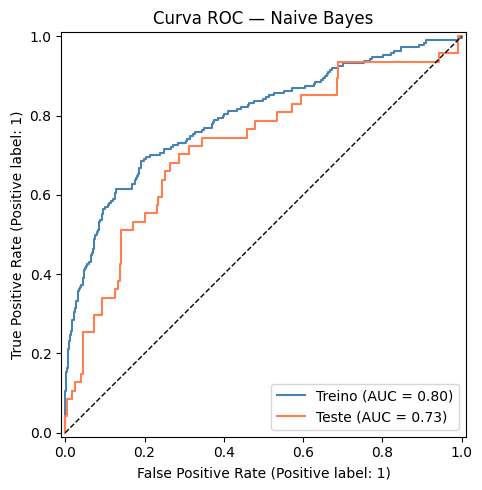

In [115]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Naive Bayes")
plt.tight_layout()
plt.savefig("roc_curve_nb.png", dpi=150, bbox_inches="tight")
plt.show()

In [116]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 179  OK
  FP — Permaneceu, previsto Saiu:       68  Erro
  FN — Saiu, previsto Permaneceu:       15  Erro (critico)
  TP — Saiu, previsto Saiu:             32  OK

  O modelo falhou em detetar 15 saidas reais (Falsos Negativos).


In [117]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 10")
print("=" * 55)
print(f"  Algoritmo:         Naive Bayes (GaussianNB)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 10
  Algoritmo:         Naive Bayes (GaussianNB)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.4752
  F1 teste:  0.4354
  Baseline:  0.3333
  Melhoria:  +0.1020


## CANDIDATO 11 — K-Nearest Neighbors (KNN)

In [118]:
# 1. IMPORTAÇÕES
from sklearn.neighbors import KNeighborsClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [119]:
# 2. TREINO DO MODELO
# Pipeline com normalização (KNN é sensível à escala)
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    KNeighborsClassifier())
])
pipeline_knn.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  K (vizinhos): {pipeline_knn.named_steps['clf'].n_neighbors}")

Modelo treinado.
  K (vizinhos): 5


In [120]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = pipeline_knn.predict(X_train)
y_proba_train = pipeline_knn.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.4223
  Precision: 0.8689
  Recall:    0.2789
  AUC-ROC:   0.9163

              precision    recall  f1-score   support

  Permaneceu       0.88      0.99      0.93       986
        Saiu       0.87      0.28      0.42       190

    accuracy                           0.88      1176
   macro avg       0.87      0.64      0.68      1176
weighted avg       0.88      0.88      0.85      1176



In [121]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = pipeline_knn.predict(X_test)
y_proba_test = pipeline_knn.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.1724
  Precision: 0.4545
  Recall:    0.1064
  AUC-ROC:   0.6464

              precision    recall  f1-score   support

  Permaneceu       0.85      0.98      0.91       247
        Saiu       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



In [122]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_knn = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_knn)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.4223,0.8689,0.2789,0.9163
1,Teste,0.1724,0.4545,0.1064,0.6464



  Diferenca F1 (treino - teste): 0.2499
  --> Sinal de OVERFITTING.


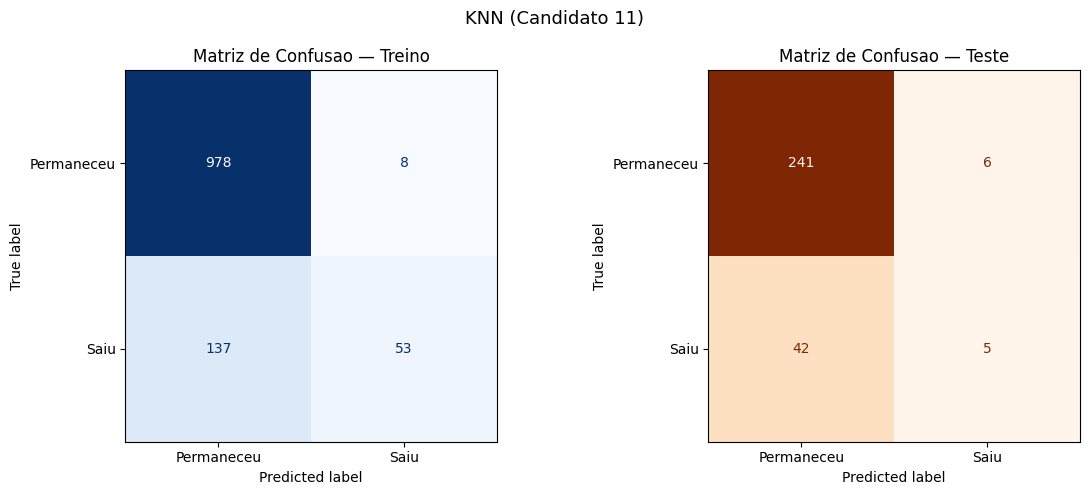

In [123]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("KNN (Candidato 11)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_knn.png", dpi=150, bbox_inches="tight")
plt.show()

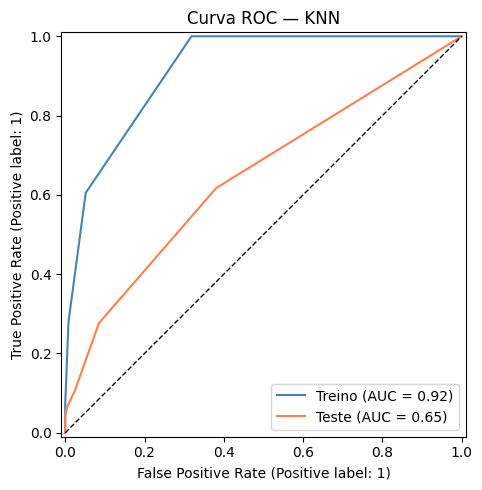

In [124]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — KNN")
plt.tight_layout()
plt.savefig("roc_curve_knn.png", dpi=150, bbox_inches="tight")
plt.show()

In [125]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 241  OK
  FP — Permaneceu, previsto Saiu:       6  Erro
  FN — Saiu, previsto Permaneceu:       42  Erro (critico)
  TP — Saiu, previsto Saiu:             5  OK

  O modelo falhou em detetar 42 saidas reais (Falsos Negativos).


In [126]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 11")
print("=" * 55)
print(f"  Algoritmo:         K-Nearest Neighbors")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 11
  Algoritmo:         K-Nearest Neighbors
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.4223
  F1 teste:  0.1724
  Baseline:  0.3333
  Melhoria:  -0.1609


## CANDIDATO 12 — Extra Trees

In [127]:
# 1. IMPORTAÇÕES
from sklearn.ensemble import ExtraTreesClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [128]:
# 2. TREINO DO MODELO
clf_et = ExtraTreesClassifier(random_state=42)
clf_et.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Numero de arvores: {clf_et.n_estimators}")

Modelo treinado.
  Numero de arvores: 100


In [129]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = clf_et.predict(X_train)
y_proba_train = clf_et.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [130]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = clf_et.predict(X_test)
y_proba_test = clf_et.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.2143
  Precision: 0.6667
  Recall:    0.1277
  AUC-ROC:   0.8099

              precision    recall  f1-score   support

  Permaneceu       0.86      0.99      0.92       247
        Saiu       0.67      0.13      0.21        47

    accuracy                           0.85       294
   macro avg       0.76      0.56      0.57       294
weighted avg       0.83      0.85      0.80       294



In [131]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_et = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_et)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.2143,0.6667,0.1277,0.8099



  Diferenca F1 (treino - teste): 0.7857
  --> Sinal de OVERFITTING.


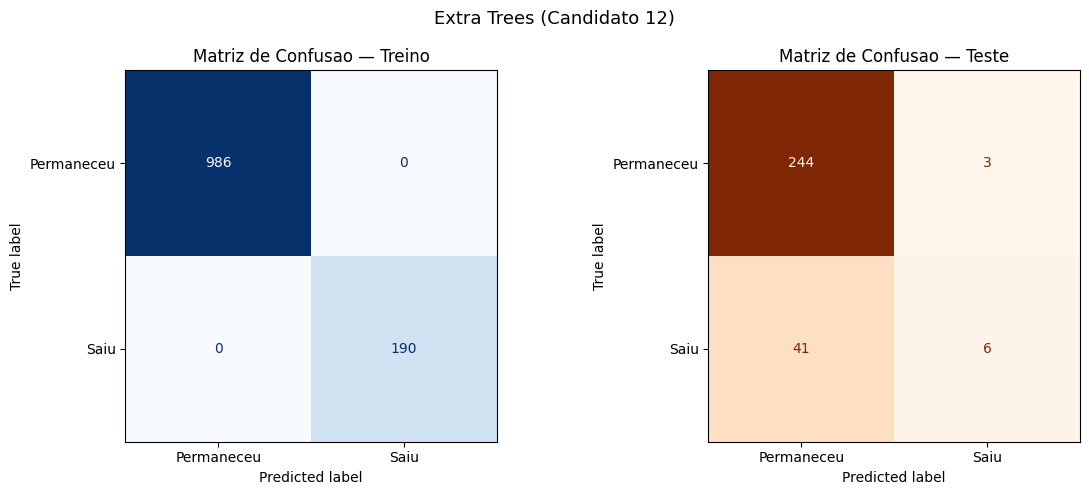

In [132]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Extra Trees (Candidato 12)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_et.png", dpi=150, bbox_inches="tight")
plt.show()

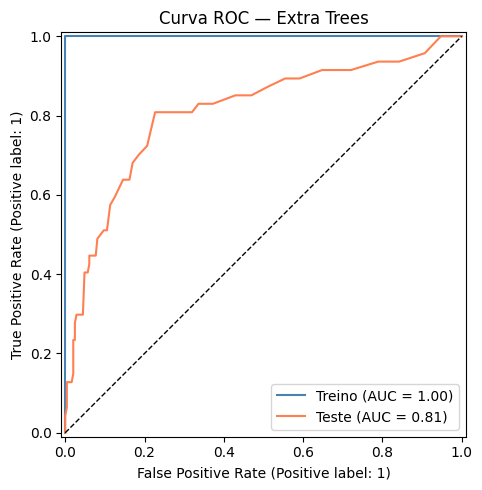

In [133]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Extra Trees")
plt.tight_layout()
plt.savefig("roc_curve_et.png", dpi=150, bbox_inches="tight")
plt.show()

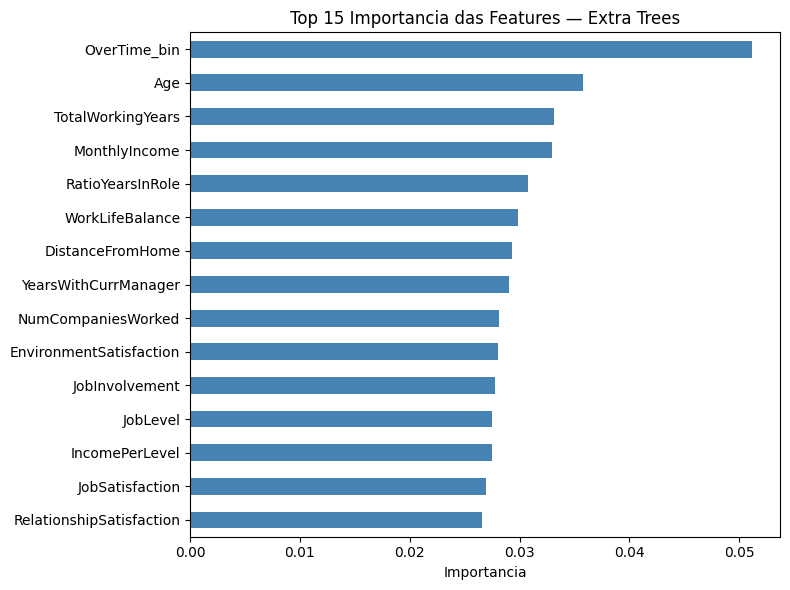

In [134]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
feat_imp_et = pd.Series(clf_et.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_et.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Extra Trees")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_et.png", dpi=150, bbox_inches="tight")
plt.show()

In [135]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 244  OK
  FP — Permaneceu, previsto Saiu:       3  Erro
  FN — Saiu, previsto Permaneceu:       41  Erro (critico)
  TP — Saiu, previsto Saiu:             6  OK

  O modelo falhou em detetar 41 saidas reais (Falsos Negativos).


In [136]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 12")
print("=" * 55)
print(f"  Algoritmo:         Extra Trees")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 12
  Algoritmo:         Extra Trees
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.2143
  Baseline:  0.3333
  Melhoria:  -0.1190


## CANDIDATO 13 — Rede Neuronal MLP (sklearn)

In [137]:
# 1. IMPORTAÇÕES
from sklearn.neural_network import MLPClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [138]:
# 2. TREINO DO MODELO
# Pipeline com normalização (redes neuronais são sensíveis à escala)
pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    MLPClassifier(random_state=42))
])
pipeline_mlp.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Camadas ocultas: {pipeline_mlp.named_steps['clf'].hidden_layer_sizes}")
print(f"  Iteracoes:       {pipeline_mlp.named_steps['clf'].n_iter_}")

Modelo treinado.
  Camadas ocultas: (100,)
  Iteracoes:       200


In [139]:
# 3. MÉTRICAS NO TREINO
y_pred_train  = pipeline_mlp.predict(X_train)
y_proba_train = pipeline_mlp.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [140]:
# 4. MÉTRICAS NO TESTE
y_pred_test  = pipeline_mlp.predict(X_test)
y_proba_test = pipeline_mlp.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4634
  Precision: 0.5429
  Recall:    0.4043
  AUC-ROC:   0.7414

              precision    recall  f1-score   support

  Permaneceu       0.89      0.94      0.91       247
        Saiu       0.54      0.40      0.46        47

    accuracy                           0.85       294
   macro avg       0.72      0.67      0.69       294
weighted avg       0.84      0.85      0.84       294



In [141]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_mlp = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_mlp)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.4634,0.5429,0.4043,0.7414



  Diferenca F1 (treino - teste): 0.5366
  --> Sinal de OVERFITTING.


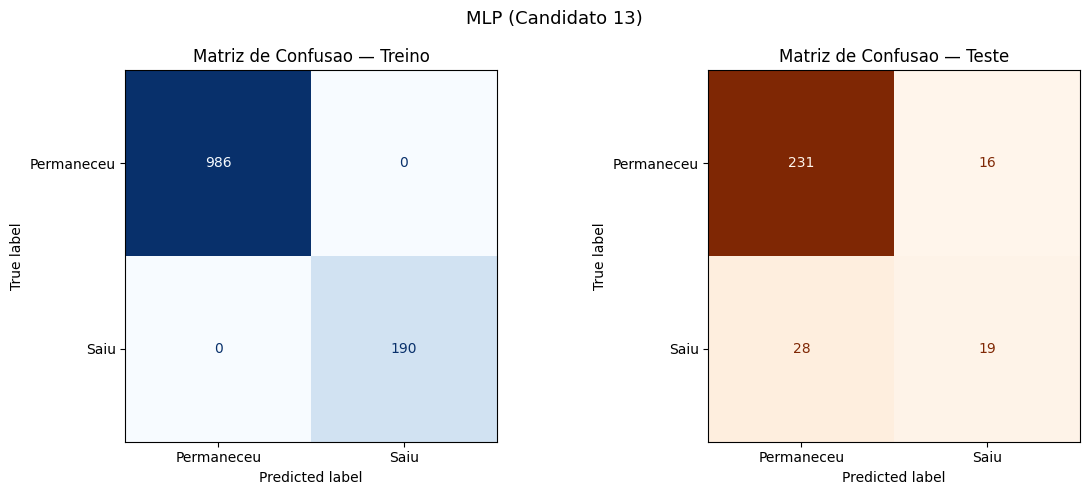

In [142]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("MLP (Candidato 13)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

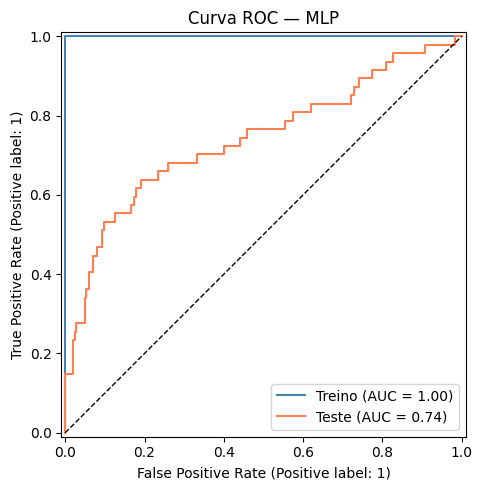

In [143]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — MLP")
plt.tight_layout()
plt.savefig("roc_curve_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

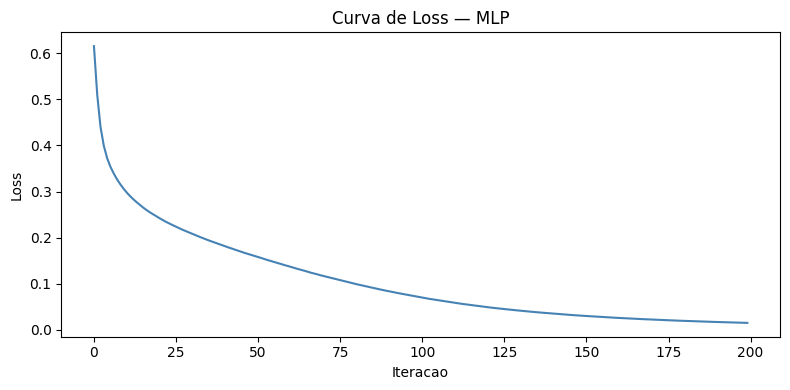

In [144]:
# 6.3 VISUALIZAÇÃO — Curva de Aprendizagem (loss durante treino)
mlp_model = pipeline_mlp.named_steps["clf"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_model.loss_curve_, color="steelblue")
ax.set_title("Curva de Loss — MLP")
ax.set_xlabel("Iteracao")
ax.set_ylabel("Loss")
plt.tight_layout()
plt.savefig("loss_curve_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

In [145]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 231  OK
  FP — Permaneceu, previsto Saiu:       16  Erro
  FN — Saiu, previsto Permaneceu:       28  Erro (critico)
  TP — Saiu, previsto Saiu:             19  OK

  O modelo falhou em detetar 28 saidas reais (Falsos Negativos).


In [146]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 13")
print("=" * 55)
print(f"  Algoritmo:         Rede Neuronal MLP (sklearn)")
print(f"  Arquitetura:       {pipeline_mlp.named_steps['clf'].hidden_layer_sizes} (default)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 13
  Algoritmo:         Rede Neuronal MLP (sklearn)
  Arquitetura:       (100,) (default)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.4634
  Baseline:  0.3333
  Melhoria:  +0.1301


## CANDIDATO 14 — Rede Neuronal TabNet (pytorch-tabnet)

In [147]:
# 1. INSTALAÇÃO E IMPORTAÇÕES
import subprocess
subprocess.run(["pip", "install", "pytorch-tabnet", "-q"], check=True)

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import StandardScaler as SS
import numpy as np
print("Bibliotecas importadas com sucesso.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.4 MB/s eta 0:00:00
Bibliotecas importadas com sucesso.


In [148]:
# 2. PREPARAÇÃO DOS DADOS (TabNet requer numpy float32)
scaler_tab = SS()
X_train_tab = scaler_tab.fit_transform(X_train).astype(np.float32)
X_test_tab  = scaler_tab.transform(X_test).astype(np.float32)
y_train_tab = y_train.values.reshape(-1)
y_test_tab  = y_test.values.reshape(-1)
print(f"X_train_tab shape: {X_train_tab.shape}")
print(f"X_test_tab shape:  {X_test_tab.shape}")

X_train_tab shape: (1176, 53)
X_test_tab shape:  (294, 53)


In [149]:
# 3. TREINO DO MODELO
# TabNetClassifier com parâmetros default
clf_tabnet = TabNetClassifier(verbose=0, seed=42)
clf_tabnet.fit(
    X_train_tab, y_train_tab,
    eval_set=[(X_test_tab, y_test_tab)],
    eval_metric=["auc"],
    batch_size=256,
    virtual_batch_size=128,
    max_epochs=100,
    patience=15,
)
print("Modelo treinado.")
print(f"  Melhor epoca: {clf_tabnet.best_epoch}")


Early stopping occurred at epoch 46 with best_epoch = 31 and best_val_0_auc = 0.74356
Modelo treinado.
  Melhor epoca: 31


In [150]:
# 4. MÉTRICAS NO TREINO
y_pred_train  = clf_tabnet.predict(X_train_tab)
y_proba_train = clf_tabnet.predict_proba(X_train_tab)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train_tab, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train_tab, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train_tab, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train_tab, y_proba_train):.4f}")
print()
print(classification_report(y_train_tab, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.5443
  Precision: 0.7217
  Recall:    0.4368
  AUC-ROC:   0.8722

              precision    recall  f1-score   support

  Permaneceu       0.90      0.97      0.93       986
        Saiu       0.72      0.44      0.54       190

    accuracy                           0.88      1176
   macro avg       0.81      0.70      0.74      1176
weighted avg       0.87      0.88      0.87      1176



In [151]:
# 5. MÉTRICAS NO TESTE
y_pred_test  = clf_tabnet.predict(X_test_tab)
y_proba_test = clf_tabnet.predict_proba(X_test_tab)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test_tab, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test_tab, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test_tab, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_tab, y_proba_test):.4f}")
print()
print(classification_report(y_test_tab, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3243
  Precision: 0.4444
  Recall:    0.2553
  AUC-ROC:   0.7436

              precision    recall  f1-score   support

  Permaneceu       0.87      0.94      0.90       247
        Saiu       0.44      0.26      0.32        47

    accuracy                           0.83       294
   macro avg       0.66      0.60      0.61       294
weighted avg       0.80      0.83      0.81       294



In [152]:
# 6. TABELA COMPARATIVA TREINO vs TESTE
resultados_tabnet = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train_tab, y_pred_train),        f1_score(y_test_tab, y_pred_test)],
    "Precision": [precision_score(y_train_tab, y_pred_train), precision_score(y_test_tab, y_pred_test)],
    "Recall":    [recall_score(y_train_tab, y_pred_train),    recall_score(y_test_tab, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train_tab, y_proba_train),  roc_auc_score(y_test_tab, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_tabnet)
diff = f1_score(y_train_tab, y_pred_train) - f1_score(y_test_tab, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.5443,0.7217,0.4368,0.8722
1,Teste,0.3243,0.4444,0.2553,0.7436



  Diferenca F1 (treino - teste): 0.2199
  --> Sinal de OVERFITTING.


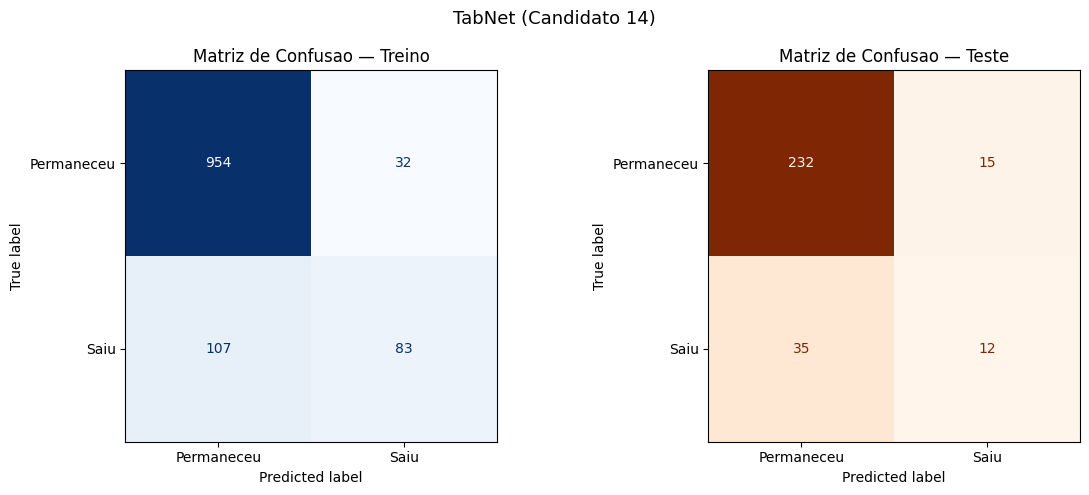

In [153]:
# 7.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train_tab, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test_tab, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("TabNet (Candidato 14)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_tabnet.png", dpi=150, bbox_inches="tight")
plt.show()

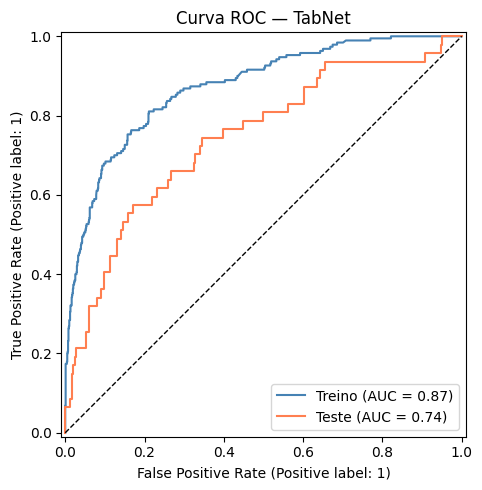

In [154]:
# 7.2 VISUALIZAÇÃO — Curva ROC
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train_tab, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test_tab,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — TabNet")
plt.tight_layout()
plt.savefig("roc_curve_tabnet.png", dpi=150, bbox_inches="tight")
plt.show()

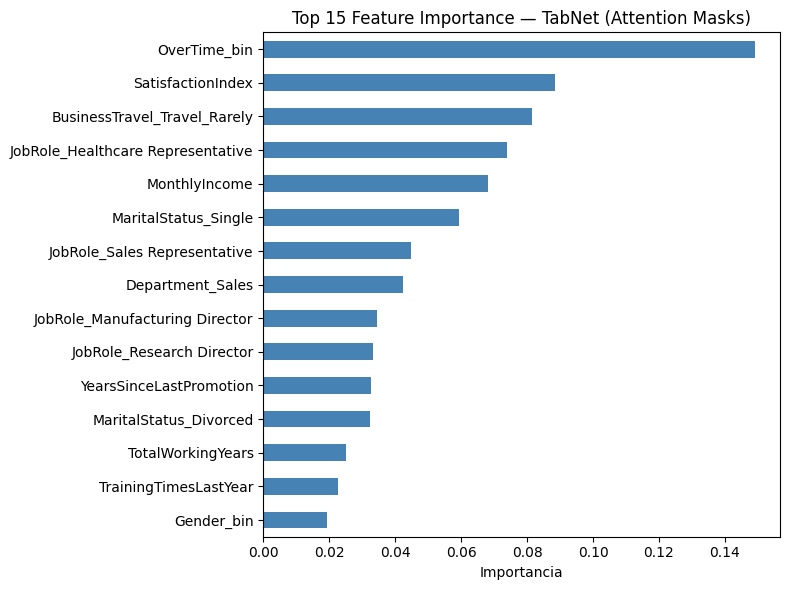

In [155]:
# 7.3 VISUALIZAÇÃO — Feature Importance (TabNet Masks)
feat_imp_tabnet = pd.Series(
    clf_tabnet.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_tabnet.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Feature Importance — TabNet (Attention Masks)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_tabnet.png", dpi=150, bbox_inches="tight")
plt.show()

In [156]:
# 8. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test_tab, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 232  OK
  FP — Permaneceu, previsto Saiu:       15  Erro
  FN — Saiu, previsto Permaneceu:       35  Erro (critico)
  TP — Saiu, previsto Saiu:             12  OK

  O modelo falhou em detetar 35 saidas reais (Falsos Negativos).


In [157]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 14")
print("=" * 55)
print(f"  Algoritmo:         TabNet (Rede Neuronal para dados tabulares)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train_tab, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test_tab, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test_tab, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 14
  Algoritmo:         TabNet (Rede Neuronal para dados tabulares)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.5443
  F1 teste:  0.3243
  Baseline:  0.3333
  Melhoria:  -0.0090


## CANDIDATO 15 — Rede Neuronal Keras

In [158]:
# 1. INSTALAÇÃO E IMPORTAÇÕES
import subprocess
subprocess.run(["pip", "install", "tensorflow", "-q"], check=True)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler as SS
import numpy as np
print(f"TensorFlow versão: {tf.__version__}")
print("Bibliotecas importadas com sucesso.")

2026-04-16 15:04:58.402182: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776351898.635986      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776351898.708913      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776351899.303018      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776351899.303056      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776351899.303059      16 computation_placer.cc:177] computation placer alr

TensorFlow versão: 2.19.0
Bibliotecas importadas com sucesso.


In [159]:
# 2. PREPARAÇÃO DOS DADOS
scaler_keras = SS()
X_train_keras = scaler_keras.fit_transform(X_train).astype(np.float32)
X_test_keras  = scaler_keras.transform(X_test).astype(np.float32)
y_train_keras = y_train.values.astype(np.float32)
y_test_keras  = y_test.values.astype(np.float32)
print(f"X_train_keras shape: {X_train_keras.shape}")
print(f"X_test_keras shape:  {X_test_keras.shape}")

X_train_keras shape: (1176, 53)
X_test_keras shape:  (294, 53)


In [160]:
# 3. TREINO DO MODELO
# Arquitetura default simples: 2 camadas ocultas (64, 32) + sigmoid
tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Input(shape=(X_train_keras.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1,  activation="sigmoid"),
])

model_keras.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

model_keras.summary()

history_keras = model_keras.fit(
    X_train_keras, y_train_keras,
    validation_data=(X_test_keras, y_test_keras),
    epochs=100,
    batch_size=32,
    verbose=0,
)
print("Modelo treinado.")
print(f"  Épocas treinadas: {len(history_keras.history['loss'])}")

2026-04-16 15:05:26.116718: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

Modelo treinado.
  Épocas treinadas: 100


In [161]:
# 4. MÉTRICAS NO TREINO
y_proba_train = model_keras.predict(X_train_keras, verbose=0).flatten()
y_pred_train  = (y_proba_train >= 0.5).astype(int)
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train_keras, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train_keras, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train_keras, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train_keras, y_proba_train):.4f}")
print()
print(classification_report(y_train_keras, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [162]:
# 5. MÉTRICAS NO TESTE
y_proba_test = model_keras.predict(X_test_keras, verbose=0).flatten()
y_pred_test  = (y_proba_test >= 0.5).astype(int)
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test_keras, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test_keras, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test_keras, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_keras, y_proba_test):.4f}")
print()
print(classification_report(y_test_keras, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.5682
  Precision: 0.6098
  Recall:    0.5319
  AUC-ROC:   0.7583

              precision    recall  f1-score   support

  Permaneceu       0.91      0.94      0.92       247
        Saiu       0.61      0.53      0.57        47

    accuracy                           0.87       294
   macro avg       0.76      0.73      0.75       294
weighted avg       0.86      0.87      0.87       294



In [163]:
# 6. TABELA COMPARATIVA TREINO vs TESTE
resultados_keras = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train_keras, y_pred_train),        f1_score(y_test_keras, y_pred_test)],
    "Precision": [precision_score(y_train_keras, y_pred_train), precision_score(y_test_keras, y_pred_test)],
    "Recall":    [recall_score(y_train_keras, y_pred_train),    recall_score(y_test_keras, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train_keras, y_proba_train),  roc_auc_score(y_test_keras, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_keras)
diff = f1_score(y_train_keras, y_pred_train) - f1_score(y_test_keras, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.5682,0.6098,0.5319,0.7583



  Diferenca F1 (treino - teste): 0.4318
  --> Sinal de OVERFITTING.


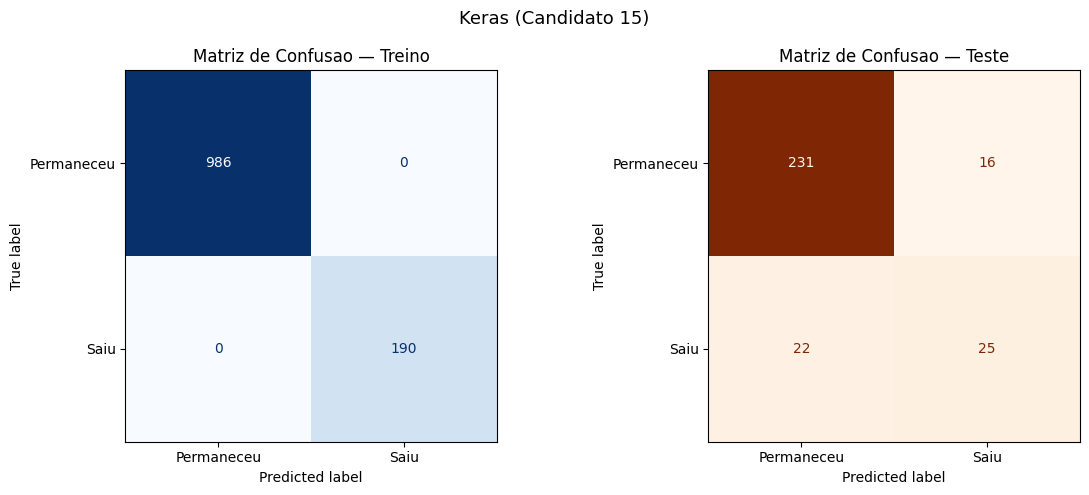

In [164]:
# 7.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train_keras, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test_keras, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Keras (Candidato 15)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_keras.png", dpi=150, bbox_inches="tight")
plt.show()

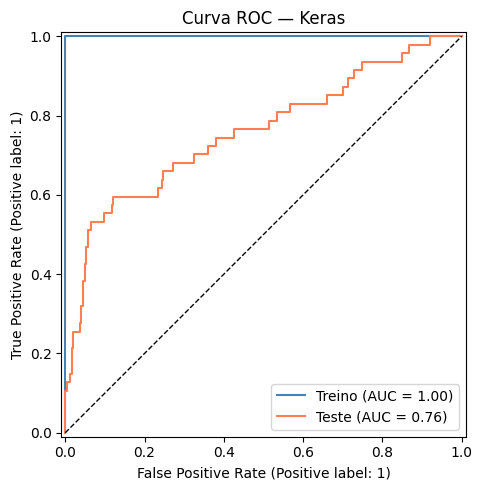

In [165]:
# 7.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train_keras, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test_keras,  y_proba_test,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Keras")
plt.tight_layout()
plt.savefig("roc_curve_keras.png", dpi=150, bbox_inches="tight")
plt.show()

Chaves disponíveis: ['AUC', 'loss', 'val_AUC', 'val_loss']
  auc_key:     AUC
  val_auc_key: val_AUC


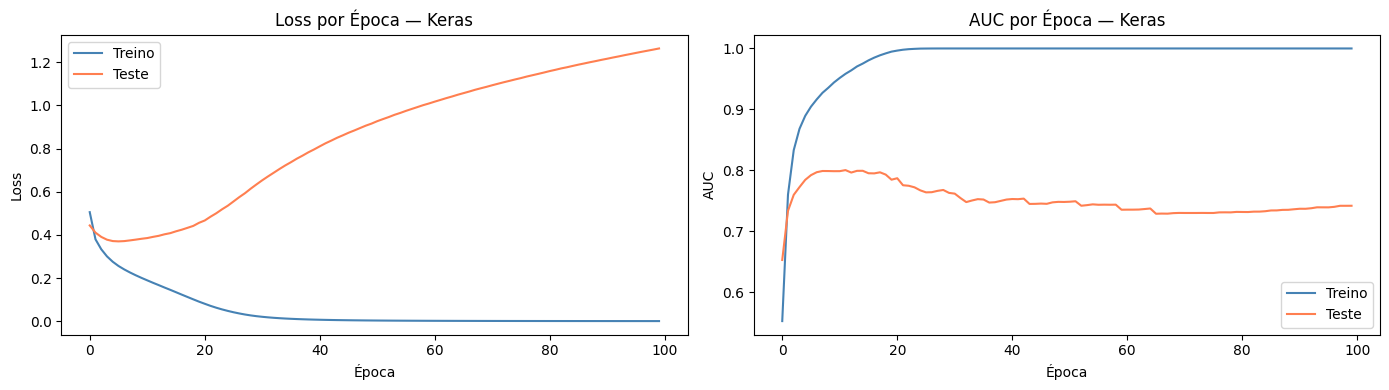

In [166]:
# 7.3 VISUALIZAÇÃO — Curvas de Loss e AUC durante treino
# Detectar a chave do AUC de forma robusta (case-insensitive)
all_keys    = list(history_keras.history.keys())
auc_key     = next((k for k in all_keys if "auc" in k.lower() and not k.lower().startswith("val_")), None)
val_auc_key = next((k for k in all_keys if "auc" in k.lower() and k.lower().startswith("val_")), None)

print(f"Chaves disponíveis: {all_keys}")
print(f"  auc_key:     {auc_key}")
print(f"  val_auc_key: {val_auc_key}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_keras.history["loss"],     label="Treino", color="steelblue")
axes[0].plot(history_keras.history["val_loss"], label="Teste",  color="coral")
axes[0].set_title("Loss por Época — Keras")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

if auc_key and val_auc_key:
    axes[1].plot(history_keras.history[auc_key],     label="Treino", color="steelblue")
    axes[1].plot(history_keras.history[val_auc_key], label="Teste",  color="coral")
    axes[1].set_title(f"AUC por Época — Keras")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Metrica AUC nao encontrada no history",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("AUC por Época — Keras")

plt.tight_layout()
plt.savefig("history_keras.png", dpi=150, bbox_inches="tight")
plt.show()

In [167]:
# 8. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test_keras, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 231  OK
  FP — Permaneceu, previsto Saiu:       16  Erro
  FN — Saiu, previsto Permaneceu:       22  Erro (critico)
  TP — Saiu, previsto Saiu:             25  OK

  O modelo falhou em detetar 22 saidas reais (Falsos Negativos).


In [168]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 15")
print("=" * 55)
print(f"  Algoritmo:         Rede Neuronal Keras (TensorFlow)")
print(f"  Arquitetura:       Input -> Dense(64,relu) -> Dense(32,relu) -> Dense(1,sigmoid)")
print(f"  Features:          {X_train_keras.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train_keras, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test_keras, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test_keras, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 15
  Algoritmo:         Rede Neuronal Keras (TensorFlow)
  Arquitetura:       Input -> Dense(64,relu) -> Dense(32,relu) -> Dense(1,sigmoid)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.5682
  Baseline:  0.3333
  Melhoria:  +0.2348


## CANDIDATO 16 — Keras com Dropout + BatchNormalization

In [169]:
# 1. IMPORTAÇÕES
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler as SS
import numpy as np
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [170]:
# 2. PREPARAÇÃO DOS DADOS
scaler_k16 = SS()
X_train_k16 = scaler_k16.fit_transform(X_train).astype(np.float32)
X_test_k16  = scaler_k16.transform(X_test).astype(np.float32)
y_train_k16 = y_train.values.astype(np.float32)
y_test_k16  = y_test.values.astype(np.float32)
print(f"X_train_k16 shape: {X_train_k16.shape}")
print(f"X_test_k16 shape:  {X_test_k16.shape}")

X_train_k16 shape: (1176, 53)
X_test_k16 shape:  (294, 53)


In [171]:
# 3. TREINO DO MODELO
# Arquitetura com Dropout e BatchNormalization para regularização
tf.random.set_seed(42)
model_k16 = keras.Sequential([
    layers.Input(shape=(X_train_k16.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model_k16.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])
model_k16.summary()
history_k16 = model_k16.fit(
    X_train_k16, y_train_k16,
    validation_data=(X_test_k16, y_test_k16),
    epochs=100, batch_size=32, verbose=0,
)
print("Modelo treinado.")
print(f"  Epocas treinadas: {len(history_k16.history['loss'])}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,049 (70.50 KB)

 Trainable params: 17,665 (69.00 KB)

 Non-trainable params: 384 (1.50 KB)

Modelo treinado.
  Epocas treinadas: 100


In [172]:
# 4. MÉTRICAS NO TREINO
y_proba_train_k16 = model_k16.predict(X_train_k16, verbose=0).flatten()
y_pred_train_k16  = (y_proba_train_k16 >= 0.5).astype(int)
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  Precision: {precision_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  Recall:    {recall_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train_k16, y_proba_train_k16):.4f}")
print()
print(classification_report(y_train_k16, y_pred_train_k16, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.9947
  Precision: 1.0000
  Recall:    0.9895
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      0.99      0.99       190

    accuracy                           1.00      1176
   macro avg       1.00      0.99      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [173]:
# 5. MÉTRICAS NO TESTE
y_proba_test_k16 = model_k16.predict(X_test_k16, verbose=0).flatten()
y_pred_test_k16  = (y_proba_test_k16 >= 0.5).astype(int)
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  Precision: {precision_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  Recall:    {recall_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_k16, y_proba_test_k16):.4f}")
print()
print(classification_report(y_test_k16, y_pred_test_k16, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3333
  Precision: 0.4194
  Recall:    0.2766
  AUC-ROC:   0.7060

              precision    recall  f1-score   support

  Permaneceu       0.87      0.93      0.90       247
        Saiu       0.42      0.28      0.33        47

    accuracy                           0.82       294
   macro avg       0.65      0.60      0.62       294
weighted avg       0.80      0.82      0.81       294



In [174]:
# 6. TABELA COMPARATIVA TREINO vs TESTE
resultados_k16 = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train_k16, y_pred_train_k16),        f1_score(y_test_k16, y_pred_test_k16)],
    "Precision": [precision_score(y_train_k16, y_pred_train_k16), precision_score(y_test_k16, y_pred_test_k16)],
    "Recall":    [recall_score(y_train_k16, y_pred_train_k16),    recall_score(y_test_k16, y_pred_test_k16)],
    "AUC-ROC":   [roc_auc_score(y_train_k16, y_proba_train_k16),  roc_auc_score(y_test_k16, y_proba_test_k16)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_k16)
diff = f1_score(y_train_k16, y_pred_train_k16) - f1_score(y_test_k16, y_pred_test_k16)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.9947,1.0000,0.9895,1.000
1,Teste,0.3333,0.4194,0.2766,0.706



  Diferenca F1 (treino - teste): 0.6614
  --> Sinal de OVERFITTING.


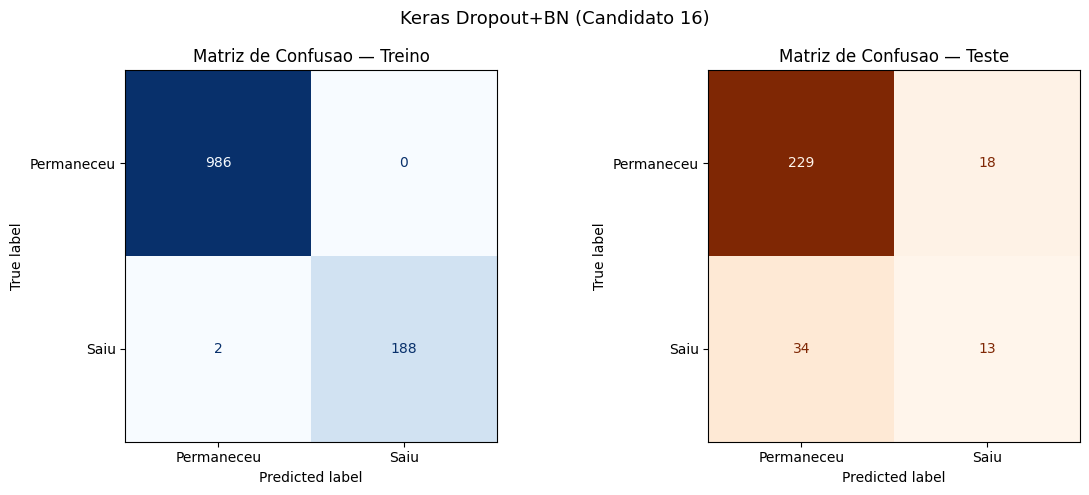

In [175]:
# 7.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train_k16, y_pred_train_k16), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test_k16, y_pred_test_k16), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Keras Dropout+BN (Candidato 16)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_k16.png", dpi=150, bbox_inches="tight")
plt.show()

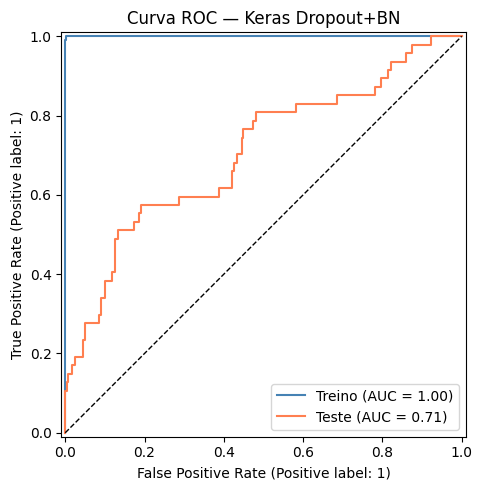

In [176]:
# 7.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train_k16, y_proba_train_k16, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test_k16,  y_proba_test_k16,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Keras Dropout+BN")
plt.tight_layout()
plt.savefig("roc_curve_k16.png", dpi=150, bbox_inches="tight")
plt.show()

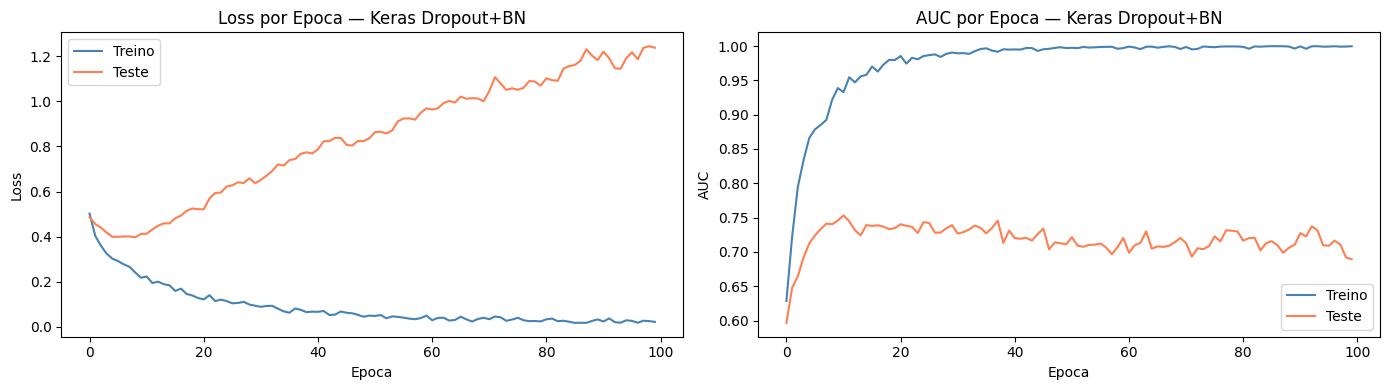

In [177]:
# 7.3 VISUALIZAÇÃO — Curvas de Loss e AUC durante treino
all_keys    = list(history_k16.history.keys())
auc_key     = next((k for k in all_keys if "auc" in k.lower() and not k.lower().startswith("val_")), None)
val_auc_key = next((k for k in all_keys if "auc" in k.lower() and k.lower().startswith("val_")), None)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_k16.history["loss"], label="Treino", color="steelblue")
axes[0].plot(history_k16.history["val_loss"], label="Teste", color="coral")
axes[0].set_title("Loss por Epoca — Keras Dropout+BN")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Loss"); axes[0].legend()
if auc_key and val_auc_key:
    axes[1].plot(history_k16.history[auc_key], label="Treino", color="steelblue")
    axes[1].plot(history_k16.history[val_auc_key], label="Teste", color="coral")
    axes[1].set_title("AUC por Epoca — Keras Dropout+BN")
    axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("AUC"); axes[1].legend()
plt.tight_layout()
plt.savefig("history_k16.png", dpi=150, bbox_inches="tight")
plt.show()

In [178]:
# 8. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test_k16, y_pred_test_k16).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 229  OK
  FP — Permaneceu, previsto Saiu:       18  Erro
  FN — Saiu, previsto Permaneceu:       34  Erro (critico)
  TP — Saiu, previsto Saiu:             13  OK

  O modelo falhou em detetar 34 saidas reais (Falsos Negativos).


In [179]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 16")
print("=" * 55)
print(f"  Algoritmo:         Keras com Dropout + BatchNormalization")
print(f"  Arquitetura:       128->BN->Drop(0.3)->64->BN->Drop(0.3)->32->1")
print(f"  Features:          {X_train_k16.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  F1 teste:  {f1_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test_k16, y_pred_test_k16) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 16
  Algoritmo:         Keras com Dropout + BatchNormalization
  Arquitetura:       128->BN->Drop(0.3)->64->BN->Drop(0.3)->32->1
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.9947
  F1 teste:  0.3333
  Baseline:  0.3333
  Melhoria:  +0.0000


## CANDIDATO 17 — GANDALF (pytorch-tabular)

In [180]:
# 1. INSTALAÇÃO E IMPORTAÇÕES
import subprocess
subprocess.run(["pip", "install", "pytorch-tabular", "-q"], check=True)

from pytorch_tabular import TabularModel
from pytorch_tabular.models import GANDALFConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
import pandas as pd
print("Bibliotecas importadas com sucesso.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 236.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 148.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 75.4 kB/s eta 0:00:00
Bibliotecas importadas com sucesso.


In [181]:
# 2. PREPARAÇÃO DOS DADOS (pytorch-tabular usa DataFrames)
feature_cols = X_train.columns.tolist()
TARGET_COL   = "Attrition_bin"

df_train_g17 = X_train.copy(); df_train_g17[TARGET_COL] = y_train.values
df_test_g17  = X_test.copy();  df_test_g17[TARGET_COL]  = y_test.values
print(f"df_train_g17 shape: {df_train_g17.shape}")
print(f"df_test_g17 shape:  {df_test_g17.shape}")

df_train_g17 shape: (1176, 54)
df_test_g17 shape:  (294, 54)


In [182]:
# 3. TREINO DO MODELO
data_config_g17 = DataConfig(
    target=[TARGET_COL],
    continuous_cols=feature_cols,
    categorical_cols=[],
)
trainer_config_g17 = TrainerConfig(
    max_epochs=50,
    batch_size=256,
    early_stopping="valid_loss",
    early_stopping_patience=10,
    checkpoints=None,
    load_best=True,
    progress_bar="none",
    trainer_kwargs={"enable_model_summary": False},
)
model_config_g17 = GANDALFConfig(task="classification")

tabular_gandalf = TabularModel(
    data_config=data_config_g17,
    model_config=model_config_g17,
    optimizer_config=OptimizerConfig(),
    trainer_config=trainer_config_g17,
    verbose=False,
)
tabular_gandalf.fit(train=df_train_g17, validation=df_test_g17)
print("Modelo treinado.")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-04-16 15:06:42,467 - {pytorch_tabular.tabular_model:1541} - WARNING - No best model available to load. Checkpoint Callback needs to be enabled for this to work


Modelo treinado.


In [183]:
# 4. MÉTRICAS NO TREINO
pred_train_g17    = tabular_gandalf.predict(df_train_g17)
y_pred_train_g17  = pred_train_g17["Attrition_bin_prediction"].values
y_proba_train_g17 = pred_train_g17["Attrition_bin_1_probability"].values
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train_g17):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train_g17):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train_g17):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train_g17):.4f}")
print()
print(classification_report(y_train, y_pred_train_g17, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.7645
  Precision: 0.9124
  Recall:    0.6579
  AUC-ROC:   0.9402

              precision    recall  f1-score   support

  Permaneceu       0.94      0.99      0.96       986
        Saiu       0.91      0.66      0.76       190

    accuracy                           0.93      1176
   macro avg       0.92      0.82      0.86      1176
weighted avg       0.93      0.93      0.93      1176



In [184]:
# 5. MÉTRICAS NO TESTE
pred_test_g17    = tabular_gandalf.predict(df_test_g17)
y_pred_test_g17  = pred_test_g17["Attrition_bin_prediction"].values
y_proba_test_g17 = pred_test_g17["Attrition_bin_1_probability"].values
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test_g17):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test_g17):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test_g17):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test_g17):.4f}")
print()
print(classification_report(y_test, y_pred_test_g17, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4938
  Precision: 0.5882
  Recall:    0.4255
  AUC-ROC:   0.7975

              precision    recall  f1-score   support

  Permaneceu       0.90      0.94      0.92       247
        Saiu       0.59      0.43      0.49        47

    accuracy                           0.86       294
   macro avg       0.74      0.68      0.71       294
weighted avg       0.85      0.86      0.85       294



In [185]:
# 6. TABELA COMPARATIVA TREINO vs TESTE
resultados_g17 = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train_g17),        f1_score(y_test, y_pred_test_g17)],
    "Precision": [precision_score(y_train, y_pred_train_g17), precision_score(y_test, y_pred_test_g17)],
    "Recall":    [recall_score(y_train, y_pred_train_g17),    recall_score(y_test, y_pred_test_g17)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train_g17),  roc_auc_score(y_test, y_proba_test_g17)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_g17)
diff = f1_score(y_train, y_pred_train_g17) - f1_score(y_test, y_pred_test_g17)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.7645,0.9124,0.6579,0.9402
1,Teste,0.4938,0.5882,0.4255,0.7975



  Diferenca F1 (treino - teste): 0.2707
  --> Sinal de OVERFITTING.


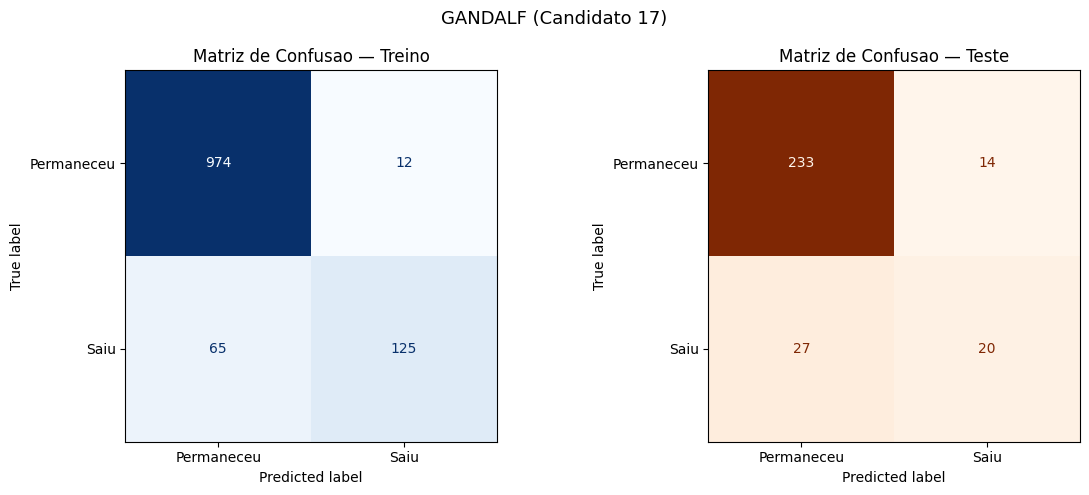

In [186]:
# 7.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train_g17), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test_g17), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("GANDALF (Candidato 17)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_gandalf.png", dpi=150, bbox_inches="tight")
plt.show()

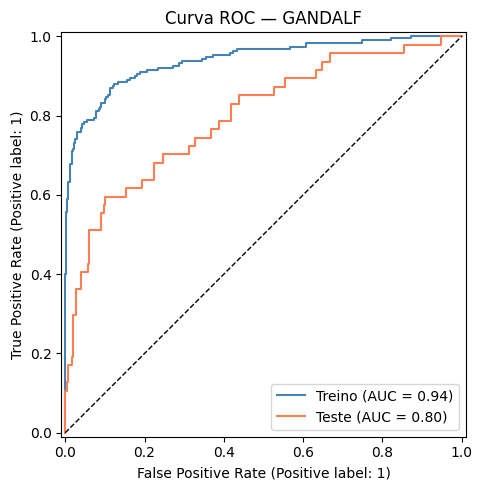

In [187]:
# 7.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train_g17, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test_g17,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — GANDALF")
plt.tight_layout()
plt.savefig("roc_curve_gandalf.png", dpi=150, bbox_inches="tight")
plt.show()

In [188]:
# 8. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test_g17).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 233  OK
  FP — Permaneceu, previsto Saiu:       14  Erro
  FN — Saiu, previsto Permaneceu:       27  Erro (critico)
  TP — Saiu, previsto Saiu:             20  OK

  O modelo falhou em detetar 27 saidas reais (Falsos Negativos).


In [189]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 17")
print("=" * 55)
print(f"  Algoritmo:         GANDALF (pytorch-tabular)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Automatica (pytorch-tabular)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train_g17):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test_g17):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test_g17) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 17
  Algoritmo:         GANDALF (pytorch-tabular)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Automatica (pytorch-tabular)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.7645
  F1 teste:  0.4938
  Baseline:  0.3333
  Melhoria:  +0.1605


## CANDIDATO 18 — FT-Transformer (pytorch-tabular)

In [190]:
# 1. IMPORTAÇÕES
from pytorch_tabular.models import FTTransformerConfig
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [191]:
# 2. PREPARAÇÃO DOS DADOS (reutiliza df_train_g17 e df_test_g17)
print(f"df_train shape: {df_train_g17.shape}")
print(f"df_test shape:  {df_test_g17.shape}")

df_train shape: (1176, 54)
df_test shape:  (294, 54)


In [192]:
# 3. TREINO DO MODELO
trainer_config_g18 = TrainerConfig(
    max_epochs=50,
    batch_size=256,
    early_stopping="valid_loss",
    early_stopping_patience=10,
    checkpoints=None,
    load_best=True,
    progress_bar="none",
    trainer_kwargs={"enable_model_summary": False},
)
model_config_g18 = FTTransformerConfig(task="classification")

tabular_ftt = TabularModel(
    data_config=data_config_g17,
    model_config=model_config_g18,
    optimizer_config=OptimizerConfig(),
    trainer_config=trainer_config_g18,
    verbose=False,
)
tabular_ftt.fit(train=df_train_g17, validation=df_test_g17)
print("Modelo treinado.")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-04-16 15:08:42,736 - {pytorch_tabular.tabular_model:1541} - WARNING - No best model available to load. Checkpoint Callback needs to be enabled for this to work


Modelo treinado.


In [193]:
# 4. MÉTRICAS NO TREINO
pred_train_g18    = tabular_ftt.predict(df_train_g17)
y_pred_train_g18  = pred_train_g18["Attrition_bin_prediction"].values
y_proba_train_g18 = pred_train_g18["Attrition_bin_1_probability"].values
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train_g18):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train_g18):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train_g18):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train_g18):.4f}")
print()
print(classification_report(y_train, y_pred_train_g18, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6463
  Precision: 0.9135
  Recall:    0.5000
  AUC-ROC:   0.8787

              precision    recall  f1-score   support

  Permaneceu       0.91      0.99      0.95       986
        Saiu       0.91      0.50      0.65       190

    accuracy                           0.91      1176
   macro avg       0.91      0.75      0.80      1176
weighted avg       0.91      0.91      0.90      1176



In [194]:
# 5. MÉTRICAS NO TESTE
pred_test_g18    = tabular_ftt.predict(df_test_g17)
y_pred_test_g18  = pred_test_g18["Attrition_bin_prediction"].values
y_proba_test_g18 = pred_test_g18["Attrition_bin_1_probability"].values
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test_g18):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test_g18):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test_g18):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test_g18):.4f}")
print()
print(classification_report(y_test, y_pred_test_g18, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4789
  Precision: 0.7083
  Recall:    0.3617
  AUC-ROC:   0.8300

              precision    recall  f1-score   support

  Permaneceu       0.89      0.97      0.93       247
        Saiu       0.71      0.36      0.48        47

    accuracy                           0.87       294
   macro avg       0.80      0.67      0.70       294
weighted avg       0.86      0.87      0.86       294



In [195]:
# 6. TABELA COMPARATIVA TREINO vs TESTE
resultados_g18 = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train_g18),        f1_score(y_test, y_pred_test_g18)],
    "Precision": [precision_score(y_train, y_pred_train_g18), precision_score(y_test, y_pred_test_g18)],
    "Recall":    [recall_score(y_train, y_pred_train_g18),    recall_score(y_test, y_pred_test_g18)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train_g18),  roc_auc_score(y_test, y_proba_test_g18)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_g18)
diff = f1_score(y_train, y_pred_train_g18) - f1_score(y_test, y_pred_test_g18)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6463,0.9135,0.5000,0.8787
1,Teste,0.4789,0.7083,0.3617,0.8300



  Diferenca F1 (treino - teste): 0.1674
  --> Sinal de OVERFITTING.


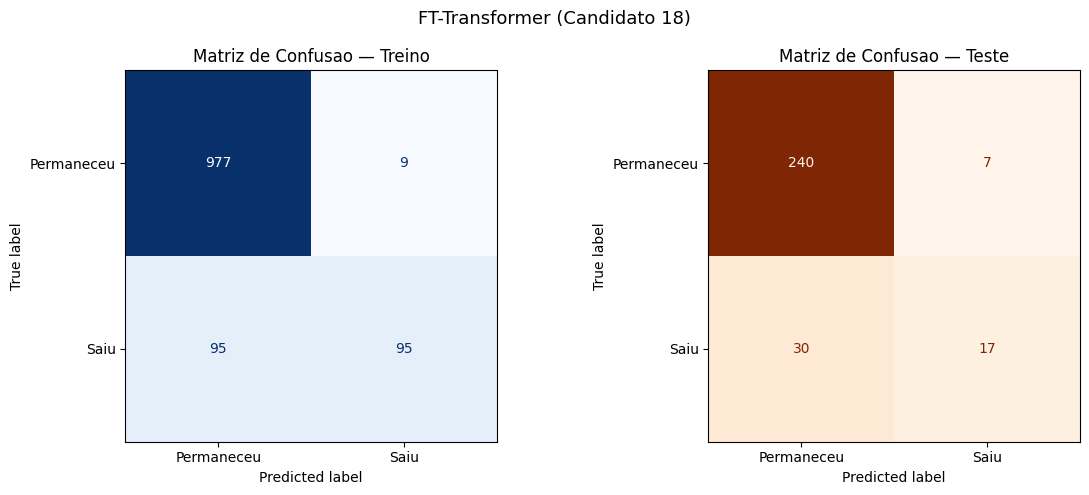

In [196]:
# 7.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train_g18), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test_g18), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("FT-Transformer (Candidato 18)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_ftt.png", dpi=150, bbox_inches="tight")
plt.show()

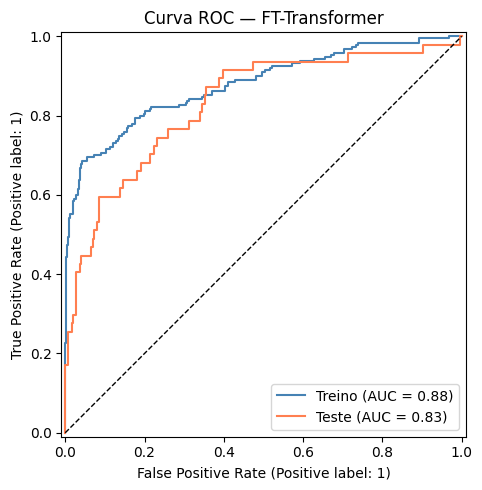

In [197]:
# 7.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train_g18, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test_g18,  name="Teste",  ax=ax, color="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — FT-Transformer")
plt.tight_layout()
plt.savefig("roc_curve_ftt.png", dpi=150, bbox_inches="tight")
plt.show()

In [198]:
# 8. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test_g18).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 240  OK
  FP — Permaneceu, previsto Saiu:       7  Erro
  FN — Saiu, previsto Permaneceu:       30  Erro (critico)
  TP — Saiu, previsto Saiu:             17  OK

  O modelo falhou em detetar 30 saidas reais (Falsos Negativos).


In [199]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 18")
print("=" * 55)
print(f"  Algoritmo:         FT-Transformer (pytorch-tabular)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Automatica (pytorch-tabular)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train_g18):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test_g18):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
print(f"  Melhoria:  {f1_score(y_test, y_pred_test_g18) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 18
  Algoritmo:         FT-Transformer (pytorch-tabular)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Automatica (pytorch-tabular)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6463
  F1 teste:  0.4789
  Baseline:  0.3333
  Melhoria:  +0.1455


In [200]:
# TABELA COMPARATIVA — TODOS OS MODELOS (Treino e Teste)

tabela_comparativa = pd.DataFrame([
    {"Modelo": "Baseline — Arvore de Decisao",
     "F1 Treino":        f1_score(y_train,        clf.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 1 — Random Forest",
     "F1 Treino":        f1_score(y_train,        clf_rf.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_rf.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_rf.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_rf.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_rf.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_rf.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_rf.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_rf.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 2 — Gradient Boosting",
     "F1 Treino":        f1_score(y_train,        clf_gb.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_gb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_gb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_gb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_gb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_gb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_gb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_gb.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 3 — XGBoost",
     "F1 Treino":        f1_score(y_train,        clf_xgb.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_xgb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_xgb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_xgb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_xgb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_xgb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_xgb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_xgb.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 4 — LightGBM",
     "F1 Treino":        f1_score(y_train,        clf_lgbm.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_lgbm.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_lgbm.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_lgbm.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_lgbm.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_lgbm.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_lgbm.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_lgbm.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 5 — CatBoost",
     "F1 Treino":        f1_score(y_train,        clf_cat.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_cat.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_cat.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_cat.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_cat.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_cat.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_cat.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_cat.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 6 — SVM",
     "F1 Treino":        f1_score(y_train,        pipeline_svm.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_svm.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_svm.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_svm.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_svm.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_svm.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_svm.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_svm.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 7 — Arvore com Pruning",
     "F1 Treino":        f1_score(y_train,        clf_pruned.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_pruned.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_pruned.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_pruned.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_pruned.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_pruned.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_pruned.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_pruned.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 8 — Regressao Logistica",
     "F1 Treino":        f1_score(y_train,        pipeline_lr.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_lr.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_lr.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_lr.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_lr.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_lr.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_lr.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_lr.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 9 — LDA",
     "F1 Treino":        f1_score(y_train,        clf_lda.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_lda.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_lda.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_lda.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_lda.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_lda.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_lda.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_lda.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 10 — Naive Bayes",
     "F1 Treino":        f1_score(y_train,        clf_nb.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_nb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_nb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_nb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_nb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_nb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_nb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_nb.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 11 — KNN",
     "F1 Treino":        f1_score(y_train,        pipeline_knn.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_knn.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_knn.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_knn.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_knn.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_knn.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_knn.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_knn.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 12 — Extra Trees",
     "F1 Treino":        f1_score(y_train,        clf_et.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_et.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_et.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_et.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_et.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_et.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_et.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_et.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 13 — MLP",
     "F1 Treino":        f1_score(y_train,        pipeline_mlp.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_mlp.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_mlp.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_mlp.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_mlp.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_mlp.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_mlp.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_mlp.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 14 — TabNet",
     "F1 Treino":        f1_score(y_train_tab,        clf_tabnet.predict(X_train_tab)),
     "Precision Treino": precision_score(y_train_tab,  clf_tabnet.predict(X_train_tab)),
     "Recall Treino":    recall_score(y_train_tab,     clf_tabnet.predict(X_train_tab)),
     "AUC Treino":       roc_auc_score(y_train_tab,    clf_tabnet.predict_proba(X_train_tab)[:, 1]),
     "F1 Teste":         f1_score(y_test_tab,          clf_tabnet.predict(X_test_tab)),
     "Precision Teste":  precision_score(y_test_tab,   clf_tabnet.predict(X_test_tab)),
     "Recall Teste":     recall_score(y_test_tab,      clf_tabnet.predict(X_test_tab)),
     "AUC Teste":        roc_auc_score(y_test_tab,     clf_tabnet.predict_proba(X_test_tab)[:, 1])},

    {"Modelo": "Candidato 15 — Keras",
     "F1 Treino":        f1_score(y_train_keras,        (model_keras.predict(X_train_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Precision Treino": precision_score(y_train_keras,  (model_keras.predict(X_train_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Recall Treino":    recall_score(y_train_keras,     (model_keras.predict(X_train_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "AUC Treino":       roc_auc_score(y_train_keras,    model_keras.predict(X_train_keras, verbose=0).flatten()),
     "F1 Teste":         f1_score(y_test_keras,          (model_keras.predict(X_test_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Precision Teste":  precision_score(y_test_keras,   (model_keras.predict(X_test_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Recall Teste":     recall_score(y_test_keras,      (model_keras.predict(X_test_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "AUC Teste":        roc_auc_score(y_test_keras,     model_keras.predict(X_test_keras, verbose=0).flatten())},

    {"Modelo": "Candidato 16 — Keras Dropout+BN",
     "F1 Treino":        f1_score(y_train_k16,        y_pred_train_k16),
     "Precision Treino": precision_score(y_train_k16,  y_pred_train_k16),
     "Recall Treino":    recall_score(y_train_k16,     y_pred_train_k16),
     "AUC Treino":       roc_auc_score(y_train_k16,    y_proba_train_k16),
     "F1 Teste":         f1_score(y_test_k16,          y_pred_test_k16),
     "Precision Teste":  precision_score(y_test_k16,   y_pred_test_k16),
     "Recall Teste":     recall_score(y_test_k16,      y_pred_test_k16),
     "AUC Teste":        roc_auc_score(y_test_k16,     y_proba_test_k16)},

    {"Modelo": "Candidato 17 — GANDALF",
     "F1 Treino":        f1_score(y_train,        y_pred_train_g17),
     "Precision Treino": precision_score(y_train,  y_pred_train_g17),
     "Recall Treino":    recall_score(y_train,     y_pred_train_g17),
     "AUC Treino":       roc_auc_score(y_train,    y_proba_train_g17),
     "F1 Teste":         f1_score(y_test,          y_pred_test_g17),
     "Precision Teste":  precision_score(y_test,   y_pred_test_g17),
     "Recall Teste":     recall_score(y_test,      y_pred_test_g17),
     "AUC Teste":        roc_auc_score(y_test,     y_proba_test_g17)},

    {"Modelo": "Candidato 18 — FT-Transformer",
     "F1 Treino":        f1_score(y_train,        y_pred_train_g18),
     "Precision Treino": precision_score(y_train,  y_pred_train_g18),
     "Recall Treino":    recall_score(y_train,     y_pred_train_g18),
     "AUC Treino":       roc_auc_score(y_train,    y_proba_train_g18),
     "F1 Teste":         f1_score(y_test,          y_pred_test_g18),
     "Precision Teste":  precision_score(y_test,   y_pred_test_g18),
     "Recall Teste":     recall_score(y_test,      y_pred_test_g18),
     "AUC Teste":        roc_auc_score(y_test,     y_proba_test_g18)},
]).round(4)

# Coluna de overfitting
tabela_comparativa["Overfitting (F1)"] = (
    tabela_comparativa["F1 Treino"] - tabela_comparativa["F1 Teste"]
).round(4).apply(lambda x: f"{x:+.4f} " if x > 0.10 else f"{x:+.4f} ✓")

# Ordenar pelo F1 Teste
tabela_comparativa = tabela_comparativa.sort_values("F1 Teste", ascending=False).reset_index(drop=True)

print("===== TABELA COMPARATIVA — TODOS OS MODELOS (TREINO E TESTE) =====")
display(tabela_comparativa)

# Modelo vencedor
melhor = tabela_comparativa.iloc[0]
print(f"\n  Modelo vencedor:   {melhor['Modelo']}")
print(f"  F1 Treino:         {melhor['F1 Treino']:.4f}")
print(f"  F1 Teste:          {melhor['F1 Teste']:.4f}")
print(f"  AUC-ROC Teste:     {melhor['AUC Teste']:.4f}")
print(f"  Overfitting (F1):  {melhor['Overfitting (F1)']}")

===== TABELA COMPARATIVA — TODOS OS MODELOS (TREINO E TESTE) =====


,Modelo,F1 Treino,Precision Treino,Recall Treino,AUC Treino,F1 Teste,Precision Teste,Recall Teste,AUC Teste,Overfitting (F1)
0,Candidato 15 — Keras,1.0000,1.0000,1.0000,1.0000,0.5682,0.6098,0.5319,0.7583,+0.4318
1,Candidato 17 — GANDALF,0.7645,0.9124,0.6579,0.9402,0.4938,0.5882,0.4255,0.7975,+0.2707
2,Candidato 18 — FT-Transformer,0.6463,0.9135,0.5000,0.8787,0.4789,0.7083,0.3617,0.8300,+0.1674
3,Candidato 13 — MLP,1.0000,1.0000,1.0000,1.0000,0.4634,0.5429,0.4043,0.7414,+0.5366
4,Candidato 8 — Regressao Logistica,0.6519,0.8175,0.5421,0.8819,0.4595,0.6296,0.3617,0.8170,+0.1924
5,Candidato 10 — Naive Bayes,0.4752,0.3583,0.7053,0.7956,0.4354,0.3200,0.6809,0.7269,+0.0398 ✓
6,Candidato 9 — LDA,0.6454,0.8211,0.5316,0.8735,0.4167,0.6000,0.3191,0.8099,+0.2287
7,Candidato 4 — LightGBM,1.0000,1.0000,1.0000,1.0000,0.3548,0.7333,0.2340,0.7820,+0.6452
8,Candidato 16 — Keras Dropout+BN,0.9947,1.0000,0.9895,1.0000,0.3333,0.4194,0.2766,0.7060,+0.6614
9,Baseline — Arvore de Decisao,1.0000,1.0000,1.0000,1.0000,0.3333,0.2951,0.3830,0.6044,+0.6667



  Modelo vencedor:   Candidato 15 — Keras
  F1 Treino:         1.0000
  F1 Teste:          0.5682
  AUC-ROC Teste:     0.7583
  Overfitting (F1):  +0.4318 


In [201]:
n_total = X_train.shape[0] + X_test.shape[0]
pct_treino = X_train.shape[0] / n_total * 100
pct_teste  = X_test.shape[0]  / n_total * 100
nome_ficheiro = f"tabela_comparativa_treino{pct_treino:.0f}_teste{pct_teste:.0f}.csv"
tabela_comparativa.to_csv(nome_ficheiro, index=False)
print(f"\n  Ficheiro guardado: {nome_ficheiro}")


  Ficheiro guardado: tabela_comparativa_treino80_teste20.csv
